# World Cup 2026: Performance and Projection

This notebook looks at the World Cup two ways, then puts them side by side.

**Part 1, observed performance.** Opponent-adjusted expected goals from raw qualifying data, 1025 matches. Raw xG ignores who you played, so each team's xG and xGA is re-based against a model of how an average side does against an opponent of a given FIFA rank, then re-centred on a neutral schedule. This part is my own analysis.

**Part 2, tournament projection.** Charts from a Monte Carlo tournament simulation. The data is external and credited. It gives title odds, a power rating, expected group goals, and group finishing probabilities for all 48 teams.

**Part 3, the bridge.** Where the two disagree, and who gets helped or hurt by their draw.

Each build cell checks the data before plotting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from math import pi
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

GROUP_COLORS = {'A':'#e74c3c','B':'#e67e22','C':'#f1c40f','D':'#2ecc71','E':'#1abc9c','F':'#3498db',
                'G':'#9b59b6','H':'#e91e63','I':'#ff5722','J':'#795548','K':'#607d8b','L':'#00bcd4'}
TIER_ORDER  = ['Elite','Strong','Mid-High','Mid-Low','Weak','Bottom']
TIER_COLORS = {'Elite':'#2ecc71','Strong':'#3498db','Mid-High':'#1abc9c','Mid-Low':'#f1c40f','Weak':'#e67e22','Bottom':'#e74c3c'}
CONF_COLORS = {'UEFA':'#3498db','CONMEBOL':'#f1c40f','CONCACAF':'#2ecc71','CAF':'#e74c3c','AFC':'#9b59b6','OFC':'#1abc9c'}
BG, PANEL, GRID, MUTED = '#0d1117', '#161b22', '#30363d', '#888888'
CREDIT_XG  = 'Opponent-adjusted xG from qualifying | @Kishloy_'
CREDIT_SIM = 'Tournament simulation (external data) | @Kishloy_'
print('Setup complete')

Setup complete


## Part 1: Observed performance (opponent-adjusted xG)

Raw match data first, so it can be checked, then the adjustment. I validated it against the five sheets that publish their own per-match averages and all matched to two decimals. Scotland and Ivory Coast have no match sheet, so they keep their old values and are flagged.

In [2]:
RAW_MATCHES = {
    'Haiti': [(1.42,0.83,100), (0.83,2.56,39), (1.36,1.53,110), (2.39,0.67,203), (1.95,0.89,107), (2.69,0.85,200), (2.08,1.57,95), (0.70,1.33,78), (1.92,1.15,123), (0.47,2.69,18), (1.90,1.49,110), (1.53,2.95,71), (1.28,1.41,133), (1.32,2.15,110), (0.96,1.67,71), (1.22,1.15,133)],
    'Qatar': [(0.83,1.42,127), (0.71,1.73,109), (0.06,1.26,39), (0.80,1.94,85), (3.67,0.40,168), (2.46,0.62,181), (1.69,0.37,99), (1.83,0.18,101), (0.32,0.84,137), (1.17,0.67,87), (0.39,1.09,83), (1.60,2.50,38), (1.37,1.93,79), (2.58,0.67,151), (1.25,1.24,151), (1.00,0.08,168), (2.95,1.15,181), (0.43,0.57,97), (2.30,0.55,152), (2.95,0.83,157), (1.27,2.08,38), (1.40,2.23,83), (0.96,1.16,97), (1.56,1.53,152), (1.01,1.62,157), (0.82,0.75,38), (0.14,2.17,83), (1.67,0.88,86), (0.85,1.54,97)],
    'Curacao': [(1.46,1.05,106), (2.26,0.78,200), (2.52,0.54,203), (1.57,2.08,127), (0.92,0.17,126), (1.02,0.69,47), (0.49,0.70,109), (0.81,1.94,122), (0.89,1.77,92), (0.70,1.71,122), (3.25,0.54,179), (1.71,1.44,92)],
    'Iraq': [(3.09,1.16,150), (0.78,1.75,15), (3.07,0.52,105), (0.86,2.24,79), (1.37,0.00,146), (2.92,0.41,146), (2.19,0.32,150), (3.90,0.42,105), (0.42,0.89,86), (0.35,0.25,151), (1.20,0.70,87), (0.93,1.11,21), (1.40,1.35,79), (0.88,1.15,86), (2.15,0.52,151), (1.33,1.60,87), (0.54,1.64,21), (0.99,0.88,79), (0.87,0.90,150), (0.51,1.83,78), (1.21,1.73,96), (1.10,1.35,96), (0.74,1.83,62)],
    'Cabo Verde': [(1.14,0.58,161), (1.33,2.40,161), (1.45,2.23,74), (0.52,1.00,73), (1.40,0.71,161), (2.99,1.74,51), (1.02,0.30,143), (0.61,1.69,44), (1.64,0.82,113), (1.76,1.26,77), (1.22,1.64,57), (1.51,0.63,147), (0.51,1.77,44), (1.53,0.60,113), (2.36,0.73,176), (1.49,1.03,176), (0.72,1.20,44), (0.98,1.40,113), (1.50,0.31,178), (0.42,0.44,73), (1.47,0.70,178), (0.90,1.07,57), (1.48,1.38,147), (1.76,0.34,161)],
    'Panama': [(0.99,0.60,70), (1.88,1.14,126), (3.05,0.45,100), (0.50,1.26,18), (2.73,1.73,39), (1.46,0.90,70), (1.45,1.14,70), (1.96,0.83,39), (0.34,1.76,92), (1.78,0.87,138), (2.46,0.51,202), (0.60,1.50,22), (0.80,1.10,18), (1.20,0.70,62), (0.50,2.30,17), (1.21,1.09,70), (2.12,1.42,70), (0.70,1.69,18), (1.06,1.78,39), (1.67,0.40,159), (1.48,0.69,133), (1.93,0.32,121), (2.39,2.09,92), (2.22,1.18,109), (1.85,1.12,120), (2.05,0.65,121), (1.28,1.36,126), (3.04,1.01,120), (1.08,2.52,121), (2.57,0.83,126)],
    'Uzbekistan': [(1.89,1.00,154), (1.80,0.93,38), (0.50,0.14,131), (2.59,0.73,181), (0.66,1.42,54), (1.30,0.49,80), (1.03,0.39,100), (5.57,0.27,130), (1.88,0.12,130), (3.34,0.53,154), (0.33,1.25,38), (1.36,0.90,152), (1.59,0.56,157), (1.37,1.30,38), (2.49,1.25,96), (2.23,1.40,100), (1.50,1.56,152), (2.91,0.14,157), (1.37,2.08,38), (0.48,1.21,96), (2.17,0.14,100)],
    'Saudi Arabia': [(2.38,0.97,188), (0.97,2.08,80), (1.12,0.91,86), (2.23,0.01,157), (2.33,0.16,81), (1.08,2.61,21), (0.72,0.72,101), (2.04,1.75,101), (2.26,0.16,188), (1.37,0.82,80), (1.86,0.33,150), (0.84,1.19,137), (1.53,1.02,15), (1.61,0.82,169), (0.49,1.29,54), (2.14,1.37,150), (2.39,0.47,137), (0.12,1.47,15), (1.13,1.56,169), (1.74,0.58,54), (1.33,0.70,127), (0.30,0.83,18), (2.19,0.52,122), (0.02,1.41,39), (2.33,1.27,150), (1.83,0.51,89)],
    'Jordan': [(1.55,1.51,101), (2.08,0.97,77), (2.35,0.52,67), (0.27,2.15,21), (0.44,0.93,169), (2.24,0.86,89), (0.73,0.76,101), (1.84,0.82,21), (1.36,2.66,100), (3.74,0.47,188), (4.29,0.23,188), (1.56,1.14,101), (0.82,1.37,77), (1.22,1.12,151), (2.59,0.85,87), (1.43,1.56,21), (2.04,0.71,86), (1.61,1.47,89), (1.94,1.49,151), (1.20,1.22,87), (1.02,1.38,21), (0.88,0.99,89)],
    'South Africa': [(1.83,1.55,141), (1.19,1.20,141), (1.34,1.49,16), (0.81,0.87,103), (0.47,0.52,114), (1.32,2.10,56), (2.30,0.36,116), (0.63,1.00,66), (0.29,2.00,16), (1.26,1.76,84), (1.40,1.10,24), (0.44,1.65,65), (0.94,2.11,24), (2.55,0.37,129), (2.49,0.11,104), (3.49,1.50,183), (1.88,1.21,142), (1.57,1.45,142), (0.88,0.48,104), (2.52,0.30,183), (1.94,0.36,177), (1.22,0.47,103), (1.22,0.82,177), (0.69,0.66,24), (2.22,0.64,129), (1.31,0.39,114), (0.44,0.89,74), (0.75,1.02,44), (1.51,1.28,129), (2.08,1.36,57)],
    'Tunisia': [(2.24,0.74,147), (1.54,1.42,147), (0.35,1.22,118), (3.47,0.32,176), (2.21,0.65,189), (2.09,0.46,145), (0.69,1.80,116), (0.52,1.10,56), (1.00,0.63,79), (1.08,0.27,118), (0.49,0.77,116), (1.29,0.67,115), (1.41,1.04,91), (2.01,0.85,95), (1.66,1.17,95), (1.52,0.83,115), (1.10,0.61,91), (1.19,1.16,141), (3.00,0.78,145), (1.95,0.72,141), (0.50,0.82,118), (2.45,0.92,189), (1.12,1.27,116), (1.39,0.55,104), (1.07,2.12,24), (1.00,0.18,135), (1.53,0.72,56)],
    'New Zealand': [(0.71,1.64,137), (1.29,1.27,137), (0.75,1.60,31), (1.11,0.99,65), (0.67,1.39,54), (1.28,1.95,28), (1.51,1.24,43), (0.65,1.10,44), (1.07,0.66,66), (0.22,1.51,39), (0.36,1.07,18), (3.36,0.67,67), (0.25,1.20,32), (0.56,1.77,42), (1.20,0.79,54), (1.10,1.43,54), (1.53,1.92,23), (1.16,2.33,11), (0.99,2.35,17), (1.03,2.87,27), (1.07,1.11,58), (1.50,0.76,48)],
    'Australia': [(3.75,0.19,186), (1.12,1.07,87), (2.13,0.16,181), (0.96,0.24,131), (1.42,0.66,72), (1.94,0.32,149), (2.08,1.67,21), (0.92,0.66,99), (3.05,0.36,99), (1.67,0.04,186), (3.58,0.58,87), (0.92,0.36,168), (3.08,0.55,149), (1.89,0.72,136), (0.42,1.89,15), (1.29,0.49,77), (1.05,0.99,168), (1.15,1.30,149), (0.93,1.09,136), (0.74,1.25,15), (0.58,1.74,77)],
    'Congo DR': [(2.54,0.20,128), (1.70,0.85,16), (0.63,0.11,135), (1.63,1.49,44), (1.88,1.09,97), (0.91,1.19,32), (1.65,0.44,79), (0.47,2.88,29), (1.33,0.52,75), (1.45,1.09,97), (0.69,0.62,155), (0.75,0.46,135), (1.66,1.57,135), (0.81,1.04,97), (1.47,0.60,155), (1.66,0.43,183), (0.41,0.52,113), (2.15,0.90,183), (1.07,1.61,29), (0.82,0.92,75), (1.21,0.26,149), (1.06,1.08,57), (1.64,1.13,24), (1.49,0.51,103), (0.95,2.01,29), (4.01,0.27,176), (0.75,1.49,45), (1.78,0.74,92)],
    'Algeria': [(1.88,0.70,161), (1.14,0.74,161), (1.53,1.12,104), (1.82,0.93,135), (0.97,1.34,142), (1.29,1.06,74), (0.86,1.65,74), (1.36,1.75,63), (2.05,1.22,113), (1.91,0.83,97), (1.42,0.75,104), (3.23,0.29,118), (2.05,0.62,140), (2.20,1.31,75), (1.04,2.11,75), (0.67,0.92,118), (2.17,0.65,140), (1.07,0.80,175), (0.90,0.26,142), (1.66,1.08,175), (0.68,0.94,97), (1.59,0.25,177), (1.49,0.94,104), (2.20,0.31,148), (2.01,1.02,63), (1.90,0.49,118), (0.70,0.16,65), (0.39,1.56,24)],
    'Ghana': [(2.27,0.88,74), (0.98,1.48,74), (1.30,1.03,115), (1.20,0.76,187), (3.17,1.05,115), (1.25,0.77,95), (1.74,2.99,84), (0.31,1.31,44), (1.78,1.22,142), (1.40,1.31,56), (2.79,0.90,187), (1.82,1.51,74), (1.03,1.10,161), (2.15,0.86,148), (0.99,1.38,148), (1.69,0.00,182), (1.20,0.95,115), (1.07,0.90,182), (0.96,1.46,56), (2.97,0.40,187), (0.48,0.25,95)],
    'Egypt': [(2.27,0.54,144), (1.18,1.23,144), (1.46,1.18,97), (2.43,1.11,154), (5.25,0.47,152), (1.42,2.71,119), (2.02,0.71,142), (1.31,0.31,51), (1.69,0.61,84), (1.49,1.63,65), (1.13,1.35,63), (0.58,0.14,111), (1.77,0.51,84), (2.44,0.77,175), (1.97,1.14,113), (0.45,0.93,113), (1.20,0.72,84), (2.47,0.44,175), (2.54,0.95,154), (0.44,0.00,119), (2.36,0.66,154), (0.95,0.57,63), (1.18,0.07,152), (1.17,0.94,111), (2.93,0.35,129), (1.01,0.75,79), (0.65,0.75,74), (1.19,1.22,103), (0.78,1.17,32), (0.47,1.52,29), (0.63,0.96,24)],
    'Canada': [(0.36,1.16,121), (2.86,1.67,147), (1.11,2.35,18), (1.72,1.02,92), (2.48,1.84,92), (1.81,0.64,122), (1.17,2.98,6), (1.80,0.80,64), (1.10,0.50,48), (1.70,0.90,36), (0.80,2.10,6), (1.90,1.60,22), (1.50,0.34,120), (1.32,0.43,120), (1.34,1.17,39), (0.99,0.86,18), (4.90,0.89,109), (0.69,1.02,98), (2.27,0.41,126), (1.34,0.85,121)],
    'Iran': [(2.47,0.63,130), (1.90,0.83,72), (1.63,0.40,87), (1.11,0.40,130), (2.35,1.21,96), (2.47,1.27,131), (1.73,0.79,15), (2.50,1.60,100), (3.59,0.29,153), (1.80,0.42,153), (4.90,0.80,130), (1.25,0.33,72), (1.48,0.87,156), (2.38,0.17,96), (1.30,1.37,72), (2.08,1.27,100), (2.59,1.89,151), (1.67,1.13,156), (1.80,0.64,96), (2.08,1.37,72), (0.75,0.82,100), (2.48,0.81,151)],
    'Mexico': [(1.61,0.66,109), (2.65,0.83,127), (1.26,0.06,100), (2.08,1.08,70), (1.33,1.09,92), (2.73,1.73,85), (0.11,0.90,109), (3.73,0.20,109), (0.83,1.96,85), (0.86,0.93,18), (0.97,0.51,92), (2.80,1.20,36), (1.00,0.40,27), (1.33,1.31,109), (2.91,0.75,109), (1.17,1.34,47), (1.78,1.06,85), (1.45,0.74,82), (1.31,0.18,120), (1.45,0.44,70), (1.41,0.02,77), (1.42,0.09,109), (1.07,0.62,18)],
    'Bosnia': [(1.41,1.11,53), (0.73,1.41,50), (0.94,1.47,3), (1.16,0.83,68), (1.30,0.76,211), (1.59,0.76,53), (3.07,0.48,211), (0.41,1.53,3), (1.02,1.18,68), (0.72,1.17,50), (0.54,1.68,35), (1.75,1.07,76), (2.12,0.47,180), (2.58,0.39,180), (1.42,1.27,20), (1.57,1.45,76), (1.57,0.93,35), (0.74,1.49,20), (0.74,0.80,26), (3.38,1.02,14)],
    'Senegal': [(2.22,1.00,142), (1.59,0.87,142), (1.12,0.88,103), (0.90,1.45,114), (4.23,1.11,183), (0.74,2.21,75), (1.88,1.00,91), (1.17,0.37,57), (1.61,0.52,97), (0.90,1.30,32), (1.11,0.47,65), (0.56,0.84,113), (0.82,1.24,63), (3.05,0.12,134), (2.70,0.36,144), (2.55,0.75,144), (1.65,1.34,63), (2.41,0.44,134), (2.09,0.00,148), (0.63,0.69,75), (1.33,0.49,148), (1.62,1.07,65), (1.33,0.26,183), (1.90,1.00,113), (3.66,0.17,175), (2.01,0.95,65), (1.94,0.76,103), (1.49,0.49,148), (1.88,1.12,56), (1.13,0.13,44), (1.63,1.87,16)],
    'Turkey': [(0.91,1.28,90), (1.01,1.56,7), (2.71,3.45,117), (1.21,0.12,26), (1.82,0.42,90), (1.47,0.84,7), (2.08,0.82,117), (1.46,0.88,26), (2.70,1.59,69), (0.65,1.83,3), (1.40,1.60,19), (1.06,2.74,20), (1.30,1.00,10), (0.72,1.73,69), (1.23,2.45,2), (2.18,0.52,110), (1.39,1.28,69), (2.12,0.88,110), (1.46,2.61,2), (1.40,0.48,35), (1.27,1.17,46)],
    'Sweden': [(1.10,1.21,9), (1.64,0.70,143), (0.85,2.77,20), (2.30,0.47,125), (1.56,1.36,20), (2.01,1.07,143), (1.59,0.38,125), (1.31,0.75,41), (0.95,1.49,46), (0.71,2.07,12), (1.14,1.15,46), (0.77,1.42,12), (0.64,2.14,41), (2.39,0.76,42), (1.15,1.82,23)],
    'Paraguay': [(1.50,0.15,64), (1.22,1.48,36), (0.12,1.35,6), (1.41,0.17,62), (0.52,0.67,48), (0.70,2.49,18), (0.80,0.70,18), (0.90,3.80,8), (1.01,0.32,70), (0.22,0.61,22), (0.43,0.87,8), (0.60,1.65,27), (1.51,0.83,36), (0.61,0.86,6), (1.07,1.14,62), (1.65,1.08,48), (1.98,1.24,18), (1.29,0.55,22), (0.63,1.51,8), (0.89,0.64,27), (1.32,1.03,64)],
    'South Korea': [(2.45,0.40,139), (2.24,0.47,136), (2.05,0.83,168), (2.17,0.27,83), (2.09,1.20,67), (2.61,1.08,77), (1.67,2.08,54), (0.82,1.84,83), (2.64,0.72,80), (1.74,0.33,80), (1.56,0.78,139), (0.78,0.04,136), (1.50,0.64,87), (1.33,0.16,86), (1.56,1.43,83), (1.11,0.93,89), (1.80,0.57,150), (1.98,0.75,87), (1.29,0.61,86), (1.38,1.02,83), (1.64,0.54,89), (2.86,0.44,150)],
    'Morocco': [(1.49,1.34,79), (2.18,0.93,140), (1.77,0.17,135), (2.53,0.03,135), (0.85,1.70,65), (2.60,0.43,128), (2.00,0.29,79), (2.37,0.52,128), (3.31,0.21,141), (3.83,4.52,78), (1.49,0.12,176), (2.01,0.98,187), (2.11,0.29,187), (1.39,1.26,78), (2.04,0.32,176), (1.95,0.66,161), (1.31,0.57,135), (2.96,0.31,161), (2.91,1.31,128), (0.91,1.36,128), (2.00,0.10,141), (1.91,0.36,95), (2.81,0.91,56), (1.94,0.20,128), (1.01,0.73,135), (1.43,0.46,57), (0.86,0.12,24), (1.87,1.63,29)],
    'Czechia': [(1.77,1.37,23), (1.49,1.17,108), (2.16,0.00,93), (1.74,0.04,60), (1.09,1.48,60), (3.39,0.14,93), (1.55,1.81,23), (2.10,0.36,108), (0.43,1.74,3), (3.00,1.10,69), (1.60,1.40,33), (2.11,0.75,93), (3.56,0.19,204), (1.74,0.79,49), (1.44,2.27,7), (2.32,2.10,49), (1.05,0.58,7), (1.51,0.89,93), (2.76,0.10,204), (1.45,1.28,43), (1.16,2.63,13)],
    'Austria': [(3.30,0.45,143), (2.69,0.83,125), (0.47,1.82,9), (2.30,0.48,31), (1.70,2.04,31), (2.49,0.53,9), (2.00,0.78,143), (1.75,0.66,125), (0.77,2.03,1), (1.89,1.60,23), (0.90,1.70,10), (2.74,1.06,33), (2.00,1.03,35), (2.72,0.76,180), (1.42,1.59,76), (1.27,1.42,30), (2.90,0.41,180), (0.62,0.99,35), (1.65,0.51,76), (1.49,0.74,30)],
    'Japan': [(3.92,0.00,157), (2.50,0.35,131), (1.75,0.71,105), (1.75,0.78,89), (2.80,0.35,149), (1.99,0.22,168), (0.79,1.73,38), (1.55,0.22,151), (2.98,0.03,157), (2.87,0.36,131), (1.88,0.02,136), (3.86,0.10,168), (1.02,1.53,77), (1.89,0.42,54), (1.60,0.99,149), (1.50,0.88,136), (1.35,0.81,168), (1.47,0.12,77), (1.25,0.74,54), (2.52,0.00,149)],
    'USA': [(1.08,1.60,92), (4.60,0.10,165), (4.36,0.75,122), (2.35,1.11,47), (1.26,0.50,85), (2.91,0.64,122), (1.76,0.91,122), (3.06,0.91,92), (0.93,0.86,39), (2.50,0.20,62), (1.10,0.80,85), (0.50,1.50,22), (0.97,1.04,92), (2.13,1.42,92), (1.69,0.70,85), (0.86,0.99,47), (3.50,0.23,122), (0.83,0.30,77), (2.69,0.47,127), (1.87,1.59,70), (1.69,1.27,121), (0.62,1.07,39)],
    'Colombia': [(1.08,0.62,36), (0.25,1.39,48), (1.69,2.43,22), (1.22,0.51,27), (1.66,0.81,9), (2.49,0.70,34), (0.70,0.80,34), (2.90,0.10,70), (1.17,0.31,9), (2.30,0.50,85), (1.20,0.80,22), (0.72,0.70,6), (1.16,0.67,64), (1.58,1.34,6), (2.31,1.55,62), (2.09,0.92,48), (1.08,1.17,22), (2.15,0.30,27), (1.15,1.83,9), (1.24,1.98,34), (1.47,0.56,64), (1.21,1.24,6), (1.79,1.00,62), (1.63,1.55,36)],
    'Uruguay': [(2.98,1.57,48), (0.52,1.69,27), (2.43,1.69,18), (0.60,0.17,8), (0.65,0.63,6), (2.98,0.14,62), (1.46,0.72,85), (2.90,0.10,62), (1.50,0.50,17), (0.90,0.60,8), (0.80,1.20,18), (1.60,1.90,47), (0.61,0.22,34), (0.52,1.91,36), (0.96,0.92,64), (1.25,0.98,27), (1.17,1.08,18), (0.76,1.53,8), (0.85,1.26,6), (0.95,2.87,62), (0.55,1.29,34), (1.45,0.73,36), (2.44,1.04,64), (0.97,1.45,48)],
    'Ecuador': [(0.17,2.34,6), (1.69,0.52,22), (0.65,1.29,62), (0.51,1.22,18), (0.26,0.44,36), (1.57,1.23,48), (0.86,1.69,36), (2.40,0.80,92), (0.40,1.00,39), (1.70,0.80,6), (0.42,0.55,8), (0.89,0.10,64), (1.65,0.60,34), (0.98,1.25,22), (3.10,0.23,62), (0.30,2.15,18), (1.79,1.20,36), (0.83,1.44,48), (0.82,0.49,8), (1.10,1.55,64), (0.64,0.89,34), (1.17,0.97,6)],
    'Belgium': [(2.57,0.71,31), (1.82,0.47,19), (2.55,0.35,125), (1.38,1.14,143), (2.21,0.22,125), (0.53,2.49,19), (1.04,0.06,143), (1.91,0.59,50), (1.80,0.83,35), (0.90,0.80,42), (0.23,1.02,1), (1.80,0.78,71), (1.76,1.50,26), (3.01,0.00,211), (3.99,0.59,61), (2.79,0.27,71), (1.77,1.20,26), (2.58,0.97,61), (3.24,0.26,211)],
    'Norway': [(0.87,1.72,2), (1.80,1.17,69), (0.95,0.80,55), (2.03,0.89,76), (1.95,0.71,69), (2.52,0.28,76), (0.72,1.24,2), (1.52,0.96,55), (2.95,0.76,108), (2.26,0.15,37), (1.59,1.31,14), (2.99,0.23,125), (9.57,0.09,108), (2.26,0.15,37), (2.03,0.15,125), (1.59,1.31,14)],
    'Switzerland': [(3.34,0.78,102), (3.03,0.18,37), (2.48,0.28,132), (2.96,2.22,35), (0.83,1.47,46), (3.25,0.00,132), (3.32,0.85,102), (2.15,0.76,37), (2.84,0.40,46), (1.26,0.50,35), (2.38,1.23,40), (0.88,0.77,55), (0.60,1.70,5), (1.30,0.55,14), (1.21,0.55,4), (1.37,0.67,46), (1.51,0.63,41), (2.07,0.71,31), (1.48,0.49,41), (1.42,0.77,31), (0.88,1.31,46)],
    'Brazil': [(3.72,0.20,62), (0.91,0.16,64), (1.21,0.60,36), (0.17,0.60,22), (0.81,1.66,18), (0.20,0.25,6), (1.70,0.90,70), (3.80,0.90,34), (0.31,1.17,18), (0.60,0.90,22), (0.55,0.42,27), (0.87,0.43,34), (1.26,0.79,48), (1.89,0.67,64), (1.10,0.94,36), (1.53,0.76,22), (1.83,1.15,18), (0.43,1.52,6), (0.49,0.82,27), (1.51,0.97,34), (2.31,0.34,48), (1.09,2.52,62)],
    'Netherlands': [(2.21,2.31,1), (5.85,0.00,204), (0.97,0.40,28), (1.31,1.43,43), (0.99,1.01,1), (2.24,0.61,28), (1.47,0.16,43), (2.44,0.00,204), (1.47,1.32,23), (0.50,1.40,1), (1.70,0.90,19), (2.75,0.28,35), (1.00,1.30,33), (0.54,1.25,4), (1.90,0.63,58), (2.86,0.00,112), (1.78,0.68,23), (2.09,0.62,107), (2.18,0.56,112), (2.05,0.76,58), (1.27,1.38,23), (2.36,0.77,107)],
    'Croatia': [(1.62,0.57,26), (1.56,1.01,33), (3.70,0.59,117), (3.45,0.20,90), (0.84,1.47,33), (1.25,0.65,26), (1.45,0.00,117), (2.31,0.17,90), (2.48,1.91,2), (2.60,1.50,60), (1.00,0.90,14), (3.36,0.32,204), (2.27,1.44,20), (2.79,0.90,93), (3.79,0.41,49), (0.58,1.05,20), (3.23,0.10,204), (2.30,0.67,93), (2.12,1.34,49)],
    'Germany': [(2.17,0.00,55), (1.52,1.13,40), (1.70,0.60,12), (2.63,1.05,13), (0.51,1.07,2), (1.61,1.11,50), (1.46,0.46,52), (3.45,0.20,68), (1.16,1.20,52), (1.79,0.78,68), (2.57,0.55,50)],
    'Portugal': [(3.39,0.03,211), (2.33,0.55,68), (1.35,0.49,30), (1.27,0.36,53), (1.16,0.81,50), (3.26,0.25,68), (5.97,0.25,50), (2.32,0.31,30), (2.94,0.24,211), (3.34,0.67,53), (1.74,0.43,20), (1.83,0.65,33), (2.00,1.60,69), (0.85,0.61,41), (0.85,0.75,1), (2.76,0.78,90), (2.03,0.58,40), (3.18,0.59,43), (2.36,0.62,40), (3.02,1.29,43), (3.69,0.62,90)],
    'Argentina': [(2.34,0.17,27), (1.22,0.03,62), (1.35,0.12,34), (1.63,0.64,64), (0.63,0.65,22), (0.25,0.20,10), (2.98,1.17,47), (2.70,0.10,48), (2.70,0.10,64), (0.80,1.70,27), (2.10,0.80,47), (0.70,0.72,18), (1.09,0.24,48), (1.34,1.58,18), (1.10,1.59,36), (1.96,0.35,62), (0.86,0.61,34), (1.07,0.23,64), (1.26,0.85,22), (1.52,0.43,10), (1.14,0.94,48), (1.24,1.21,18), (2.05,0.50,36), (0.97,1.17,27)],
    'France': [(2.31,2.21,8), (0.74,0.57,43), (4.16,0.06,204), (2.89,0.24,28), (2.74,0.37,43), (1.01,0.99,8), (7.86,0.00,204), (1.39,1.06,28), (2.03,0.77,18), (1.40,0.50,8), (2.30,1.20,23), (1.02,0.23,10), (0.75,0.93,5), (1.10,1.25,2), (1.91,0.93,42), (2.34,0.82,53), (3.48,0.13,143), (2.54,0.53,53), (3.01,0.15,42), (1.93,0.37,143)],
    'Spain': [(1.37,0.95,11), (1.37,1.28,55), (4.79,0.26,69), (3.10,0.09,76), (2.28,1.49,55), (1.03,0.83,11), (2.11,0.34,76), (2.06,0.46,69), (2.48,1.91,9), (1.90,0.18,14), (1.37,0.46,60), (3.06,0.24,69), (0.57,1.07,4), (0.75,1.10,1), (1.80,0.50,3), (3.19,0.31,110), (2.45,1.23,33), (2.64,0.19,110), (3.73,0.27,69), (1.81,2.61,33)],
    'England': [(2.08,0.93,14), (1.52,0.04,42), (2.44,0.00,112), (3.30,0.00,71), (1.14,0.21,42), (1.64,1.51,14), (0.67,0.25,112), (1.29,1.79,71), (0.54,0.17,25), (0.85,0.81,13), (0.80,0.15,41), (1.24,1.25,50), (0.55,1.21,12), (1.25,0.54,8), (0.50,1.80,2), (1.75,0.27,60), (3.13,0.31,117), (2.57,0.32,132), (1.99,0.17,132), (2.81,0.33,25), (2.90,0.57,117), (2.08,0.66,25), (1.80,0.78,60)],
}

In [3]:
BASE = {
    'Algeria': dict(group='J', gf_pg=2.4, ga_pg=0.8, shots=14.4, sot=4.9, corners=6.3, old_xg=1.84, old_xga=0.85),
    'Argentina': dict(group='J', gf_pg=1.73, ga_pg=0.56, shots=11.78, sot=4.5, corners=4.34, old_xg=1.72, old_xga=0.72),
    'Australia': dict(group='D', gf_pg=2.38, ga_pg=0.44, shots=11.44, sot=4.69, corners=5.13, old_xg=0.88, old_xga=1.3),
    'Austria': dict(group='J', gf_pg=2.75, ga_pg=0.5, shots=13.38, sot=6.75, corners=4.38, old_xg=2.13, old_xga=0.9),
    'Belgium': dict(group='G', gf_pg=3.63, ga_pg=0.88, shots=22.25, sot=8.0, corners=10.38, old_xg=2.71, old_xga=0.68),
    'Bosnia': dict(group='B', gf_pg=1.9, ga_pg=0.9, shots=16.0, sot=4.87, corners=4.6, old_xg=2.14, old_xga=1.35),
    'Brazil': dict(group='C', gf_pg=1.34, ga_pg=0.95, shots=11.95, sot=4.11, corners=5.17, old_xg=1.91, old_xga=0.74),
    'Cabo Verde': dict(group='H', gf_pg=1.6, ga_pg=0.8, shots=12.4, sot=4.7, corners=5.5, old_xg=1.45, old_xga=1.13),
    'Canada': dict(group='B', gf_pg=2.5, ga_pg=0.5, shots=11.25, sot=4.25, corners=6.75, old_xg=1.54, old_xga=0.93),
    'Colombia': dict(group='K', gf_pg=1.56, ga_pg=1.0, shots=13.73, sot=5.33, corners=4.12, old_xg=1.46, old_xga=0.88),
    'Congo DR': dict(group='K', gf_pg=1.42, ga_pg=0.59, shots=8.8, sot=2.9, corners=5.8, old_xg=1.4, old_xga=0.71),
    'Croatia': dict(group='L', gf_pg=3.25, ga_pg=0.5, shots=22.63, sot=8.5, corners=9.25, old_xg=2.28, old_xga=0.82),
    'Curacao': dict(group='E', gf_pg=2.8, ga_pg=0.5, shots=16.3, sot=6.4, corners=4.7, old_xg=1.35, old_xga=1.18),
    'Czechia': dict(group='A', gf_pg=2.2, ga_pg=1.2, shots=16.3, sot=6.0, corners=7.5, old_xg=1.62, old_xga=1.17),
    'Ecuador': dict(group='E', gf_pg=0.78, ga_pg=0.28, shots=10.73, sot=3.83, corners=3.95, old_xg=1.1, old_xga=0.78),
    'Egypt': dict(group='G', gf_pg=2.0, ga_pg=0.2, shots=15.1, sot=5.8, corners=5.7, old_xg=1.44, old_xga=0.99),
    'England': dict(group='L', gf_pg=2.75, ga_pg=0.0, shots=18.88, sot=7.88, corners=7.5, old_xg=2.12, old_xga=0.72),
    'France': dict(group='I', gf_pg=2.67, ga_pg=0.67, shots=21.84, sot=7.67, corners=6.84, old_xg=2.36, old_xga=1.2),
    'Germany': dict(group='E', gf_pg=2.6, ga_pg=0.5, shots=17.17, sot=6.17, corners=5.84, old_xg=2.36, old_xga=0.96),
    'Ghana': dict(group='L', gf_pg=2.3, ga_pg=0.3, shots=12.9, sot=4.9, corners=4.8, old_xg=1.12, old_xga=1.09),
    'Haiti': dict(group='C', gf_pg=2.0, ga_pg=1.3, shots=16.5, sot=5.7, corners=4.6, old_xg=1.37, old_xga=1.13),
    'Iran': dict(group='G', gf_pg=2.19, ga_pg=0.75, shots=10.75, sot=5.75, corners=2.07, old_xg=1.48, old_xga=0.79),
    'Iraq': dict(group='I', gf_pg=1.5, ga_pg=0.65, shots=7.3, sot=2.0, corners=3.3, old_xg=1.13, old_xga=1.1),
    'Ivory Coast': dict(group='E', gf_pg=2.5, ga_pg=0.0, shots=16.0, sot=5.7, corners=6.9, old_xg=2.1, old_xga=0.59),
    'Japan': dict(group='F', gf_pg=3.4, ga_pg=0.2, shots=16.07, sot=3.53, corners=7.2, old_xg=1.73, old_xga=1.08),
    'Jordan': dict(group='J', gf_pg=2.0, ga_pg=0.75, shots=10.19, sot=2.37, corners=4.07, old_xg=1.59, old_xga=1.4),
    'Mexico': dict(group='A', gf_pg=1.66, ga_pg=0.3, shots=14.0, sot=6.0, corners=5.67, old_xg=1.17, old_xga=0.79),
    'Morocco': dict(group='C', gf_pg=2.75, ga_pg=0.25, shots=11.63, sot=5.9, corners=5.13, old_xg=1.69, old_xga=0.63),
    'Netherlands': dict(group='F', gf_pg=3.38, ga_pg=0.5, shots=17.38, sot=6.5, corners=6.5, old_xg=2.18, old_xga=0.66),
    'New Zealand': dict(group='G', gf_pg=5.8, ga_pg=0.2, shots=14.0, sot=6.0, corners=5.0, old_xg=0.87, old_xga=1.38),
    'Norway': dict(group='I', gf_pg=4.63, ga_pg=0.63, shots=19.38, sot=7.75, corners=5.0, old_xg=2.45, old_xga=0.68),
    'Panama': dict(group='L', gf_pg=1.9, ga_pg=0.5, shots=16.6, sot=6.1, corners=6.3, old_xg=1.77, old_xga=1.34),
    'Paraguay': dict(group='D', gf_pg=0.78, ga_pg=0.56, shots=11.0, sot=3.72, corners=4.5, old_xg=0.98, old_xga=1.17),
    'Portugal': dict(group='K', gf_pg=3.34, ga_pg=1.17, shots=25.0, sot=8.33, corners=6.84, old_xg=2.63, old_xga=0.95),
    'Qatar': dict(group='B', gf_pg=2.06, ga_pg=1.56, shots=13.45, sot=3.67, corners=5.62, old_xg=0.74, old_xga=1.15),
    'Saudi Arabia': dict(group='H', gf_pg=1.23, ga_pg=0.73, shots=13.34, sot=4.5, corners=4.84, old_xg=1.36, old_xga=1.12),
    'Scotland': dict(group='C', gf_pg=2.17, ga_pg=1.17, shots=11.17, sot=4.83, corners=4.5, old_xg=1.62, old_xga=1.4),
    'Senegal': dict(group='I', gf_pg=2.2, ga_pg=0.3, shots=13.9, sot=5.7, corners=4.8, old_xg=1.88, old_xga=0.78),
    'South Africa': dict(group='A', gf_pg=1.7, ga_pg=0.6, shots=12.55, sot=4.55, corners=6.4, old_xg=1.25, old_xga=0.91),
    'South Korea': dict(group='A', gf_pg=2.5, ga_pg=0.5, shots=13.63, sot=3.25, corners=6.07, old_xg=1.4, old_xga=0.99),
    'Spain': dict(group='H', gf_pg=3.5, ga_pg=0.34, shots=22.84, sot=9.67, corners=7.17, old_xg=2.83, old_xga=0.66),
    'Sweden': dict(group='F', gf_pg=1.25, ga_pg=1.88, shots=9.5, sot=3.0, corners=4.88, old_xg=1.38, old_xga=1.88),
    'Switzerland': dict(group='B', gf_pg=2.34, ga_pg=0.33, shots=10.84, sot=5.33, corners=4.34, old_xg=1.63, old_xga=0.92),
    'Tunisia': dict(group='F', gf_pg=2.2, ga_pg=0.0, shots=12.2, sot=4.9, corners=4.8, old_xg=1.26, old_xga=0.97),
    'Turkey': dict(group='D', gf_pg=2.38, ga_pg=1.5, shots=13.13, sot=4.63, corners=6.0, old_xg=1.38, old_xga=1.21),
    'USA': dict(group='D', gf_pg=2.2, ga_pg=1.0, shots=13.3, sot=5.67, corners=5.17, old_xg=1.78, old_xga=1.29),
    'Uruguay': dict(group='H', gf_pg=1.23, ga_pg=0.67, shots=10.45, sot=3.22, corners=4.39, old_xg=0.98, old_xga=0.96),
    'Uzbekistan': dict(group='K', gf_pg=1.69, ga_pg=0.69, shots=10.82, sot=3.06, corners=3.32, old_xg=1.78, old_xga=0.82),
}

In [4]:
def build_xg():
    A=[];D=[];L=[]
    for ms in RAW_MATCHES.values():
        for a,d,r in ms: A.append(a);D.append(d);L.append(np.log(r))
    A=np.array(A);D=np.array(D);L=np.array(L)
    g_xgf,g_xga=A.mean(),D.mean()
    ba,ia=np.polyfit(L,A,1); bd,idd=np.polyfit(L,D,1)
    rows=[]
    for t,b in BASE.items():
        if t in RAW_MATCHES:
            ms=RAW_MATCHES[t]
            a=np.array([m[0] for m in ms]);d=np.array([m[1] for m in ms]);r=np.array([m[2] for m in ms]);Lt=np.log(r)
            rows.append(dict(team=t,group=b['group'],adj_xg=round(g_xgf+(a-(ba*Lt+ia)).mean(),2),
                             adj_xga=round(g_xga+(d-(bd*Lt+idd)).mean(),2),
                             raw_xg=round(a.mean(),2),raw_xga=round(d.mean(),2),
                             sos=round(r.mean(),0),adjusted=True,
                             shots=b['shots'],sot=b['sot'],corners=b['corners'],gf_pg=b['gf_pg']))
        else:
            rows.append(dict(team=t,group=b['group'],adj_xg=b['old_xg'],adj_xga=b['old_xga'],
                             raw_xg=b['old_xg'],raw_xga=b['old_xga'],sos=np.nan,adjusted=False,
                             shots=b['shots'],sot=b['sot'],corners=b['corners'],gf_pg=b['gf_pg']))
    return pd.DataFrame(rows)

xg_df=build_xg(); adj=xg_df[xg_df['adjusted']]
print(f"{len(xg_df)} teams | {xg_df['adjusted'].sum()} adjusted | legacy: {', '.join(xg_df.loc[~xg_df['adjusted'],'team'])}")
xg_df.sort_values('adj_xg',ascending=False).head(10)[['team','group','sos','raw_xg','adj_xg','raw_xga','adj_xga']]

48 teams | 46 adjusted | legacy: Ivory Coast, Scotland


,team,group,sos,raw_xg,adj_xg,raw_xga,adj_xga
17,France,I,55.0,2.35,2.59,0.67,0.52
33,Portugal,K,64.0,2.46,2.55,0.59,0.54
30,Norway,I,61.0,2.35,2.50,0.75,0.65
40,Spain,H,47.0,2.19,2.45,0.79,0.63
11,Croatia,L,71.0,2.25,2.33,0.80,0.75
28,Netherlands,F,58.0,1.91,2.17,0.81,0.65
23,Ivory Coast,E,NaN,2.10,2.10,0.59,0.59
18,Germany,E,42.0,1.87,2.09,0.74,0.61
42,Switzerland,B,50.0,1.93,2.08,0.80,0.71
4,Belgium,G,77.0,1.99,2.05,0.75,0.71


### 1a. Attack vs Defense (opponent-adjusted, observed)

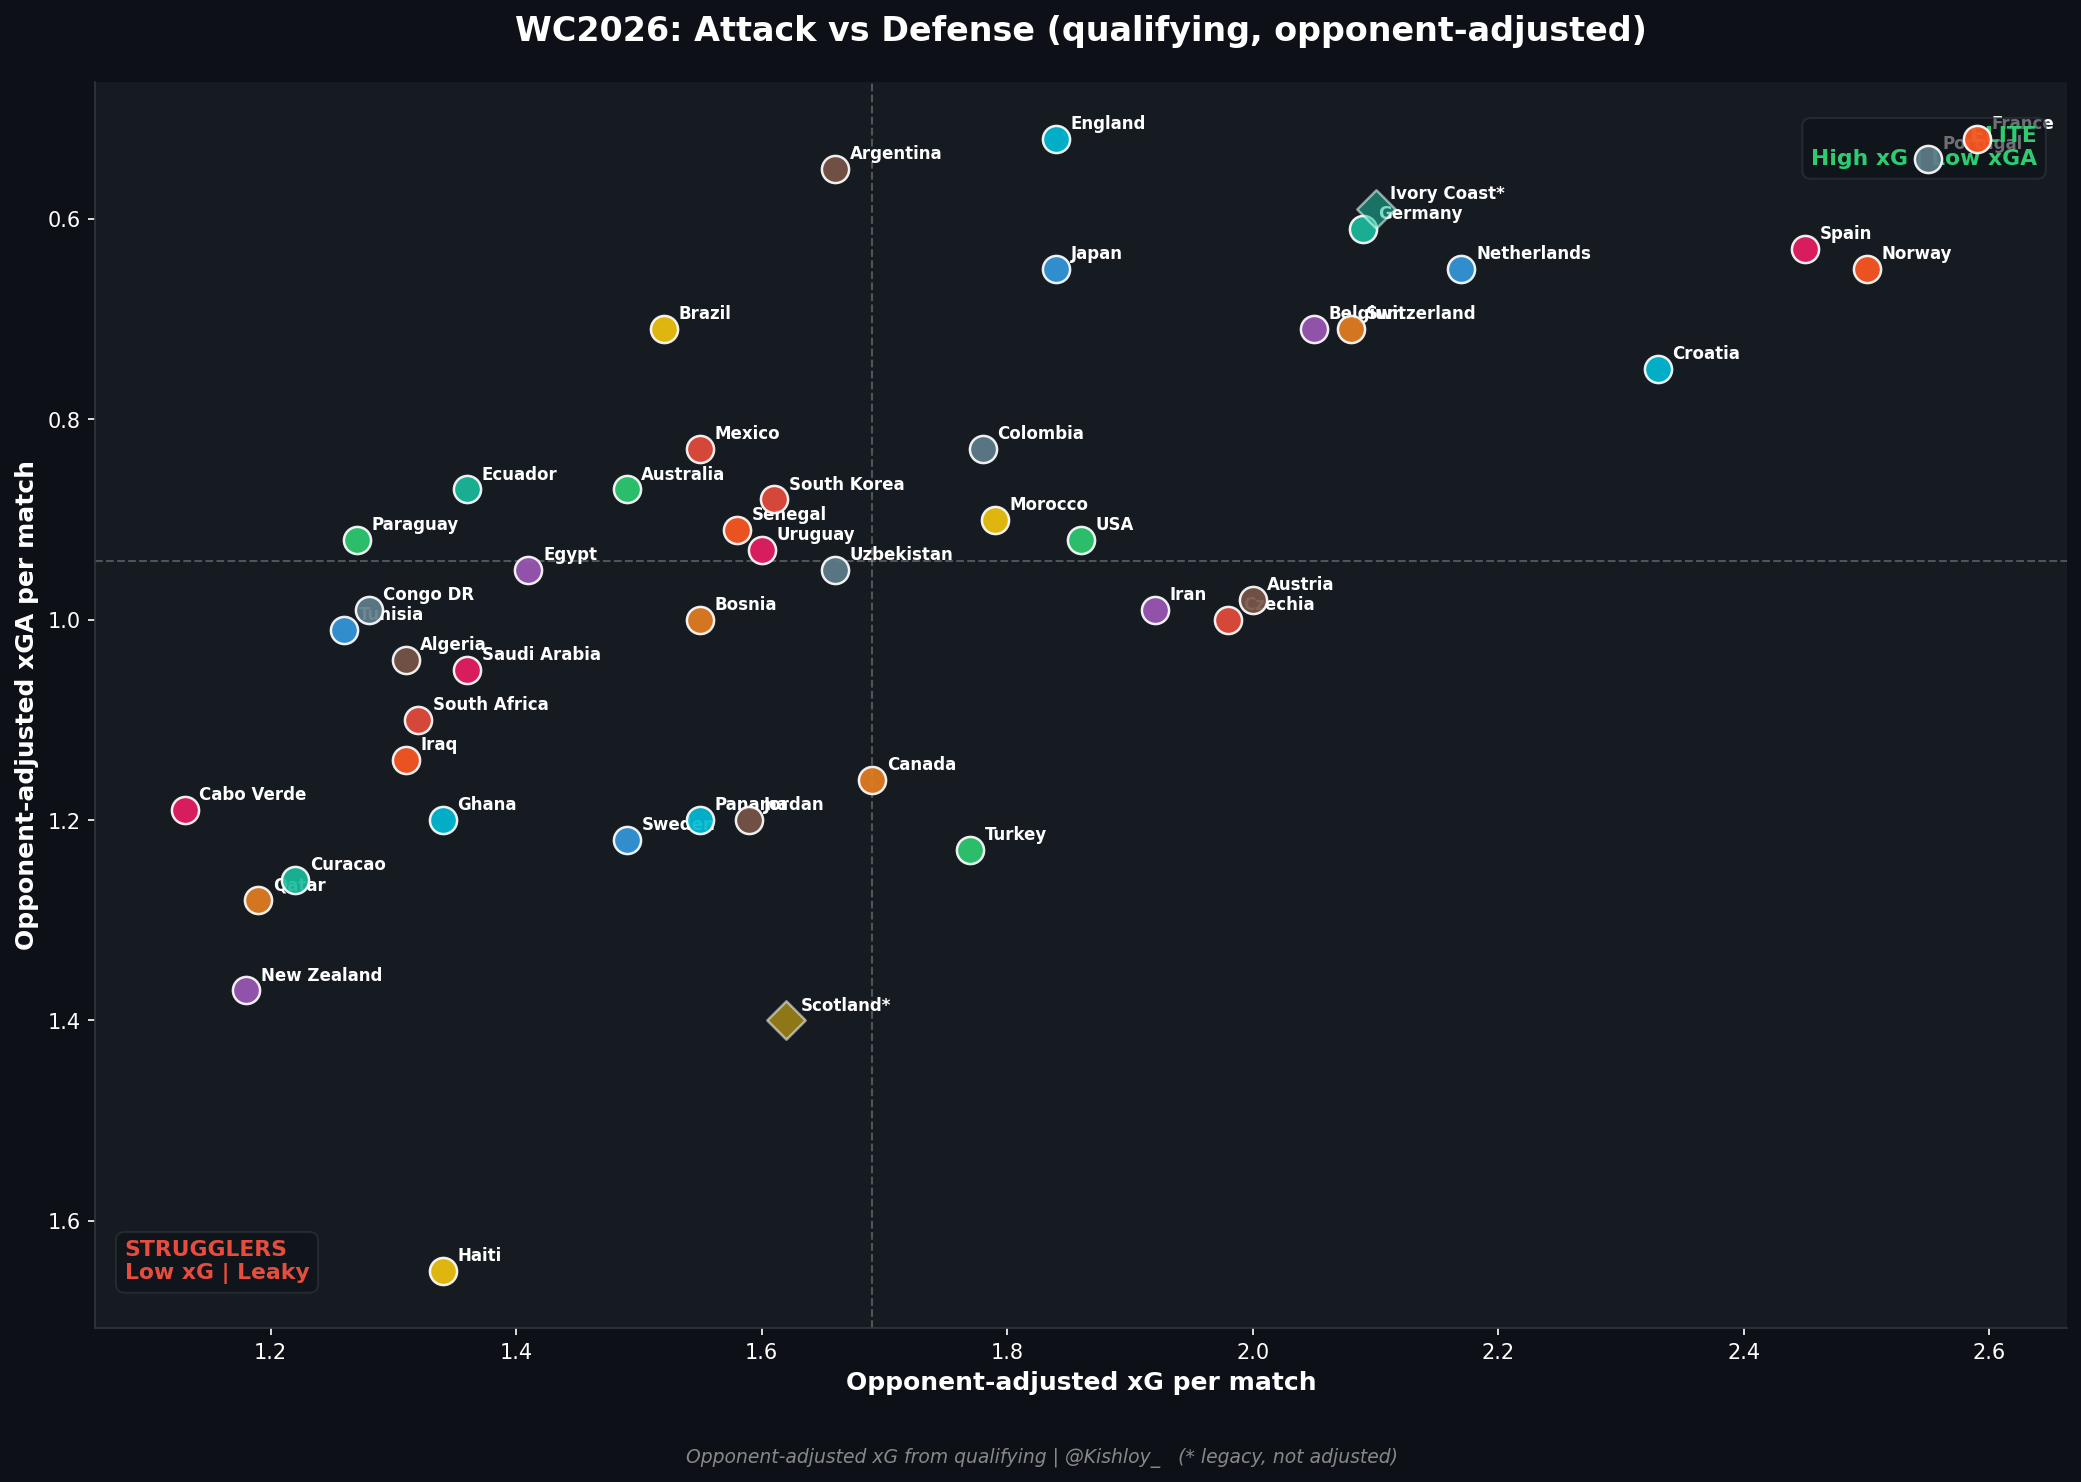

In [5]:
fig,ax=plt.subplots(figsize=(14,10));fig.patch.set_facecolor(BG);ax.set_facecolor(PANEL)
for _,r in xg_df.iterrows():
    ax.scatter(r['adj_xg'],r['adj_xga'],color=GROUP_COLORS[r['group']],s=170,zorder=5,
               alpha=0.55 if not r['adjusted'] else 0.92,edgecolors='white',linewidth=1.2,
               marker='D' if not r['adjusted'] else 'o')
    ax.annotate(r['team']+('*' if not r['adjusted'] else ''),(r['adj_xg'],r['adj_xga']),
                fontsize=8,color='white',xytext=(7,5),textcoords='offset points',fontweight='bold')
ax.axvline(xg_df['adj_xg'].mean(),color='white',alpha=0.25,ls='--',lw=1)
ax.axhline(xg_df['adj_xga'].mean(),color='white',alpha=0.25,ls='--',lw=1)
zb=dict(boxstyle='round,pad=0.4',facecolor=BG,edgecolor=GRID,alpha=0.6)
ax.text(0.985,0.965,'ELITE\nHigh xG | Low xGA',transform=ax.transAxes,color='#2ecc71',fontsize=10.5,ha='right',va='top',fontweight='bold',bbox=zb)
ax.text(0.015,0.035,'STRUGGLERS\nLow xG | Leaky',transform=ax.transAxes,color='#e74c3c',fontsize=10.5,ha='left',va='bottom',fontweight='bold',bbox=zb)
ax.set_xlabel('Opponent-adjusted xG per match',color='white',fontsize=12,fontweight='bold')
ax.set_ylabel('Opponent-adjusted xGA per match',color='white',fontsize=12,fontweight='bold')
ax.set_title('WC2026: Attack vs Defense (qualifying, opponent-adjusted)',color='white',fontsize=16,fontweight='bold',pad=20)
ax.tick_params(colors='white',labelsize=10)
for sp in ax.spines.values():sp.set_color(GRID)
ax.invert_yaxis()
fig.text(0.5,0.02,CREDIT_XG+'   (* legacy, not adjusted)',ha='center',color=MUTED,fontsize=9,style='italic')
plt.tight_layout(rect=[0,0.05,1,1]);plt.savefig('m1_xg_map.png',dpi=200,bbox_inches='tight',facecolor=BG);plt.show()

### 1b. Best attacks and defenses by adjusted xG

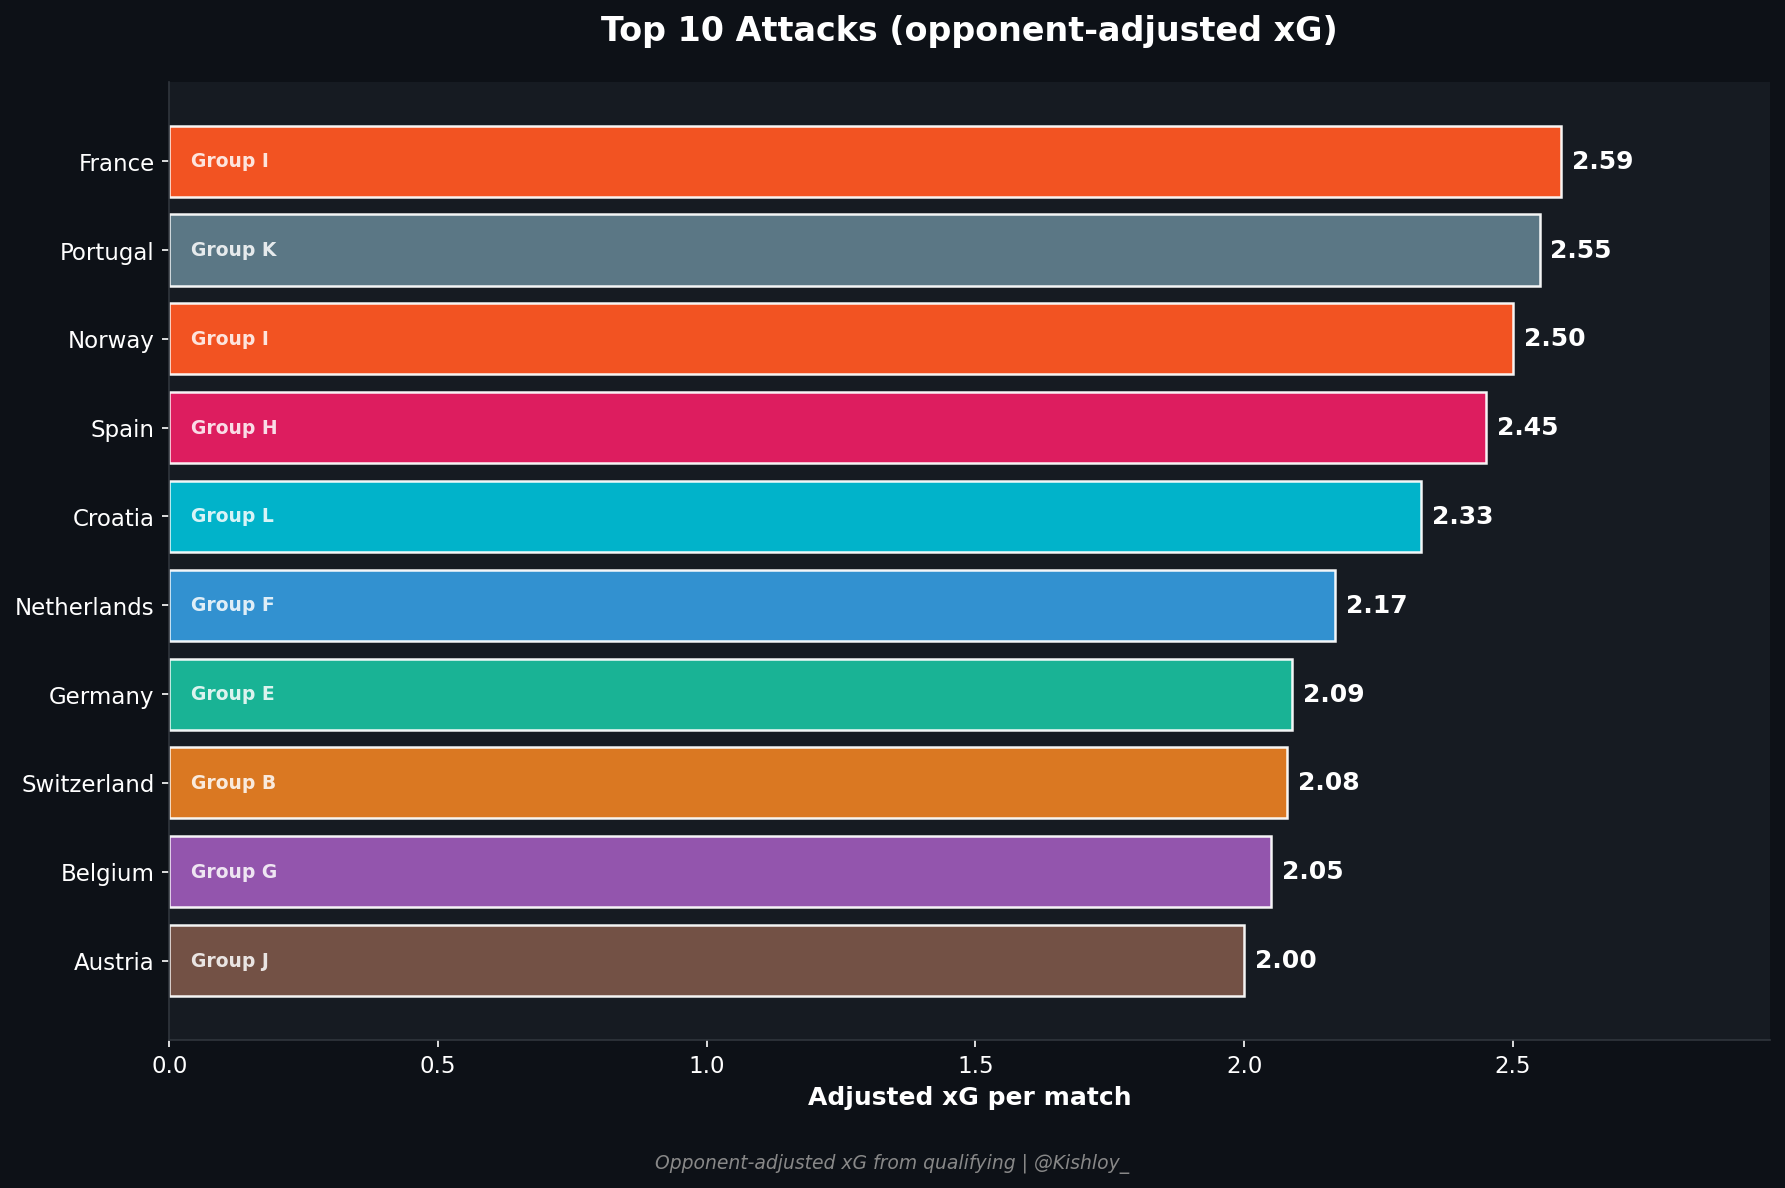

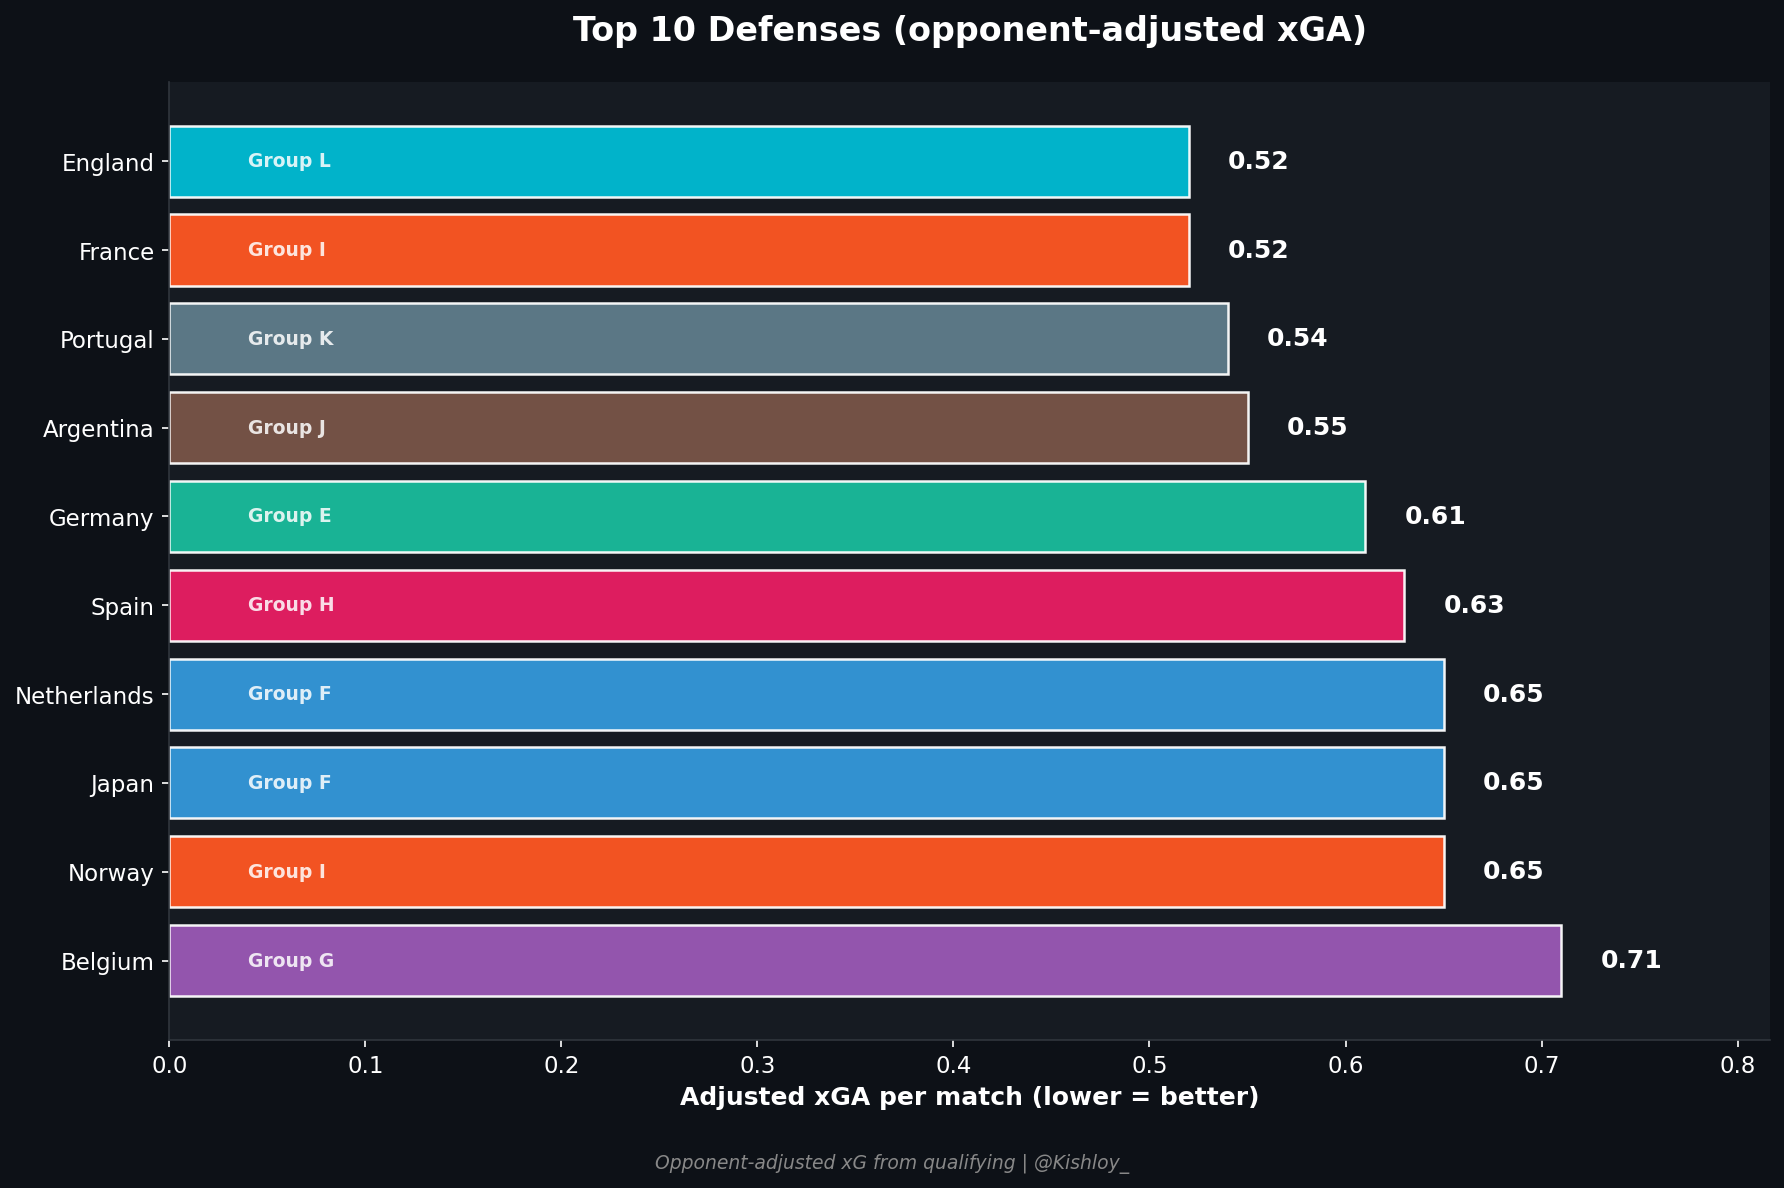

In [6]:
for metric,asc,fname,title,xlab in [
    ('adj_xg',False,'m2_top_attack.png','Top 10 Attacks (opponent-adjusted xG)','Adjusted xG per match'),
    ('adj_xga',True,'m3_top_defense.png','Top 10 Defenses (opponent-adjusted xGA)','Adjusted xGA per match (lower = better)')]:
    sub=(adj.nsmallest(10,metric) if asc else adj.nlargest(10,metric)).sort_values(metric,ascending=not asc)
    fig,ax=plt.subplots(figsize=(12,8));fig.patch.set_facecolor(BG);ax.set_facecolor(PANEL)
    bars=ax.barh(sub['team'],sub[metric],color=[GROUP_COLORS[g] for g in sub['group']],edgecolor='white',linewidth=1.2,alpha=0.95)
    for bar,val,grp in zip(bars,sub[metric],sub['group']):
        ax.text(val+0.02,bar.get_y()+bar.get_height()/2,f'{val:.2f}',va='center',color='white',fontsize=12,fontweight='bold')
        ax.text(0.04,bar.get_y()+bar.get_height()/2,f'Group {grp}',va='center',color='white',alpha=0.85,fontsize=9,fontweight='bold')
    ax.set_xlabel(xlab,color='white',fontsize=12,fontweight='bold')
    ax.set_title(title,color='white',fontsize=16,fontweight='bold',pad=20)
    ax.tick_params(colors='white',labelsize=11)
    for sp in ax.spines.values():sp.set_color(GRID)
    ax.set_xlim(0,sub[metric].max()*1.15)
    fig.text(0.5,0.02,CREDIT_XG,ha='center',color=MUTED,fontsize=9,style='italic')
    plt.tight_layout(rect=[0,0.05,1,1]);plt.savefig(fname,dpi=200,bbox_inches='tight',facecolor=BG);plt.show()

## Part 2: Tournament projection (simulation)

Simulation output by Jamie Davies (https://x.com/jamiedavies02), used with credit. `win_prob` is implied from the decimal title odds, so it includes the bookmaker margin. `sim_xg` and `sim_xga` are the simulation's expected group goals per match (group total divided by 3), a projection that already reflects the real group draw.

In [7]:
SIM = {
    'Spain': dict(group='H', tier='Elite', win_odds=7.13, index=33.7, supremacy=8.08, g_pts=7.3, g_gf=7.46, g_ga=1.75, g_gd=5.71, p=(0.75, 0.2, 0.04, 0.01)),
    'France': dict(group='I', tier='Elite', win_odds=8.59, index=30.8, supremacy=5.81, g_pts=6.4, g_gf=5.95, g_ga=2.25, g_gd=3.69, p=(0.6, 0.26, 0.12, 0.02)),
    'Argentina': dict(group='J', tier='Elite', win_odds=10.66, index=28.1, supremacy=5.61, g_pts=6.7, g_gf=5.98, g_ga=2.0, g_gd=3.98, p=(0.64, 0.24, 0.1, 0.02)),
    'Germany': dict(group='E', tier='Elite', win_odds=11.58, index=27.1, supremacy=6.54, g_pts=6.8, g_gf=7.19, g_ga=2.23, g_gd=4.96, p=(0.6, 0.27, 0.12, 0.01)),
    'England': dict(group='L', tier='Elite', win_odds=11.79, index=27.1, supremacy=5.3, g_pts=6.6, g_gf=5.73, g_ga=2.05, g_gd=3.68, p=(0.65, 0.24, 0.08, 0.02)),
    'Brazil': dict(group='C', tier='Strong', win_odds=12.76, index=26.3, supremacy=6.17, g_pts=6.5, g_gf=4.65, g_ga=1.88, g_gd=2.77, p=(0.71, 0.21, 0.07, 0.01)),
    'Portugal': dict(group='K', tier='Strong', win_odds=17.18, index=23.1, supremacy=4.55, g_pts=6.3, g_gf=5.75, g_ga=2.28, g_gd=3.47, p=(0.5, 0.35, 0.12, 0.03)),
    'Belgium': dict(group='G', tier='Strong', win_odds=23.56, index=21.4, supremacy=4.35, g_pts=6.4, g_gf=5.61, g_ga=2.15, g_gd=3.46, p=(0.65, 0.22, 0.09, 0.03)),
    'Netherlands': dict(group='F', tier='Strong', win_odds=26.77, index=18.7, supremacy=3.04, g_pts=5.9, g_gf=5.04, g_ga=2.48, g_gd=2.55, p=(0.52, 0.27, 0.15, 0.06)),
    'Uruguay': dict(group='H', tier='Strong', win_odds=30.72, index=17.3, supremacy=2.1, g_pts=5.4, g_gf=4.64, g_ga=2.82, g_gd=1.82, p=(0.21, 0.54, 0.19, 0.07)),
    'Colombia': dict(group='K', tier='Mid-High', win_odds=37.11, index=16.9, supremacy=2.3, g_pts=5.5, g_gf=4.47, g_ga=2.49, g_gd=1.98, p=(0.41, 0.38, 0.15, 0.06)),
    'USA': dict(group='D', tier='Mid-High', win_odds=45.25, index=15.1, supremacy=1.57, g_pts=5.0, g_gf=4.22, g_ga=2.96, g_gd=1.26, p=(0.36, 0.29, 0.22, 0.14)),
    'Mexico': dict(group='A', tier='Mid-High', win_odds=51.55, index=16.0, supremacy=2.81, g_pts=5.9, g_gf=4.66, g_ga=2.12, g_gd=2.54, p=(0.54, 0.26, 0.14, 0.05)),
    'Croatia': dict(group='L', tier='Mid-High', win_odds=54.35, index=13.3, supremacy=0.91, g_pts=4.8, g_gf=4.0, g_ga=3.06, g_gd=0.95, p=(0.23, 0.42, 0.24, 0.11)),
    'Morocco': dict(group='C', tier='Mid-High', win_odds=56.5, index=13.8, supremacy=1.25, g_pts=4.9, g_gf=4.29, g_ga=2.96, g_gd=1.33, p=(0.2, 0.49, 0.23, 0.08)),
    'Norway': dict(group='I', tier='Mid-High', win_odds=62.5, index=13.6, supremacy=1.39, g_pts=5.0, g_gf=4.73, g_ga=3.27, g_gd=1.46, p=(0.24, 0.4, 0.28, 0.08)),
    'Ecuador': dict(group='E', tier='Mid-High', win_odds=63.69, index=13.4, supremacy=1.12, g_pts=4.9, g_gf=4.14, g_ga=2.92, g_gd=1.23, p=(0.26, 0.39, 0.28, 0.07)),
    'Austria': dict(group='J', tier='Mid-High', win_odds=67.8, index=12.2, supremacy=0.75, g_pts=4.7, g_gf=4.27, g_ga=3.26, g_gd=1.0, p=(0.2, 0.38, 0.32, 0.09)),
    'Senegal': dict(group='I', tier='Mid-High', win_odds=77.82, index=11.7, supremacy=-0.01, g_pts=4.2, g_gf=3.78, g_ga=3.69, g_gd=0.09, p=(0.14, 0.29, 0.42, 0.15)),
    'Switzerland': dict(group='B', tier='Mid-Low', win_odds=101.01, index=13.3, supremacy=2.5, g_pts=5.9, g_gf=5.0, g_ga=2.31, g_gd=2.69, p=(0.43, 0.33, 0.19, 0.05)),
    'Japan': dict(group='F', tier='Mid-Low', win_odds=103.09, index=10.4, supremacy=0.1, g_pts=4.4, g_gf=3.73, g_ga=3.29, g_gd=0.44, p=(0.28, 0.32, 0.25, 0.15)),
    'Turkey': dict(group='D', tier='Mid-Low', win_odds=143.88, index=10.7, supremacy=0.71, g_pts=4.8, g_gf=4.09, g_ga=3.1, g_gd=0.99, p=(0.34, 0.27, 0.23, 0.16)),
    'Ivory Coast': dict(group='E', tier='Mid-Low', win_odds=143.88, index=11.5, supremacy=0.01, g_pts=4.3, g_gf=3.85, g_ga=3.39, g_gd=0.47, p=(0.13, 0.3, 0.46, 0.11)),
    'Paraguay': dict(group='D', tier='Mid-Low', win_odds=166.67, index=8.4, supremacy=-0.76, g_pts=3.7, g_gf=3.06, g_ga=3.59, g_gd=-0.53, p=(0.2, 0.24, 0.28, 0.28)),
    'South Korea': dict(group='A', tier='Mid-Low', win_odds=196.08, index=9.2, supremacy=-0.25, g_pts=4.1, g_gf=3.38, g_ga=3.35, g_gd=0.03, p=(0.19, 0.29, 0.29, 0.23)),
    'Egypt': dict(group='G', tier='Mid-Low', win_odds=256.41, index=8.8, supremacy=-0.22, g_pts=4.3, g_gf=3.48, g_ga=3.21, g_gd=0.27, p=(0.2, 0.39, 0.27, 0.15)),
    'Canada': dict(group='B', tier='Mid-Low', win_odds=298.51, index=10.5, supremacy=1.24, g_pts=5.3, g_gf=4.37, g_ga=2.63, g_gd=1.74, p=(0.37, 0.32, 0.24, 0.07)),
    'Algeria': dict(group='J', tier='Mid-Low', win_odds=333.33, index=6.9, supremacy=-1.22, g_pts=3.8, g_gf=3.39, g_ga=3.87, g_gd=-0.49, p=(0.15, 0.31, 0.38, 0.16)),
    'Czechia': dict(group='A', tier='Mid-Low', win_odds=377.36, index=7.7, supremacy=-0.74, g_pts=3.9, g_gf=3.23, g_ga=3.5, g_gd=-0.27, p=(0.2, 0.3, 0.29, 0.21)),
    'Sweden': dict(group='F', tier='Mid-Low', win_odds=400.0, index=6.1, supremacy=-1.44, g_pts=3.6, g_gf=3.14, g_ga=3.89, g_gd=-0.75, p=(0.14, 0.26, 0.34, 0.26)),
    'Australia': dict(group='D', tier='Weak', win_odds=1250.0, index=4.7, supremacy=-2.19, g_pts=2.9, g_gf=2.72, g_ga=4.45, g_gd=-1.73, p=(0.12, 0.2, 0.27, 0.41)),
    'Bosnia': dict(group='B', tier='Weak', win_odds=1666.67, index=6.0, supremacy=-1.06, g_pts=3.9, g_gf=3.4, g_ga=3.59, g_gd=-0.2, p=(0.18, 0.26, 0.41, 0.15)),
    'Tunisia': dict(group='F', tier='Weak', win_odds=1818.18, index=3.3, supremacy=-2.76, g_pts=2.5, g_gf=2.38, g_ga=4.62, g_gd=-2.25, p=(0.07, 0.15, 0.26, 0.53)),
    'Scotland': dict(group='C', tier='Weak', win_odds=2222.22, index=5.5, supremacy=-1.63, g_pts=3.6, g_gf=3.23, g_ga=4.04, g_gd=-0.81, p=(0.06, 0.24, 0.45, 0.25)),
    'Congo DR': dict(group='K', tier='Weak', win_odds=2222.22, index=3.7, supremacy=-2.8, g_pts=2.7, g_gf=2.55, g_ga=4.71, g_gd=-2.16, p=(0.06, 0.17, 0.43, 0.34)),
    'Iran': dict(group='G', tier='Bottom', win_odds=2500.0, index=4.9, supremacy=-1.79, g_pts=3.4, g_gf=2.85, g_ga=3.84, g_gd=-0.99, p=(0.11, 0.26, 0.38, 0.26)),
    'Ghana': dict(group='L', tier='Weak', win_odds=2857.14, index=4.5, supremacy=-2.35, g_pts=3.1, g_gf=2.79, g_ga=4.46, g_gd=-1.67, p=(0.07, 0.22, 0.39, 0.32)),
    'South Africa': dict(group='A', tier='Weak', win_odds=2857.14, index=3.4, supremacy=-2.74, g_pts=2.5, g_gf=2.22, g_ga=4.52, g_gd=-2.3, p=(0.06, 0.16, 0.27, 0.5)),
    'Saudi Arabia': dict(group='H', tier='Bottom', win_odds=5000.0, index=2.3, supremacy=-4.22, g_pts=2.1, g_gf=2.09, g_ga=5.84, g_gd=-3.75, p=(0.02, 0.13, 0.35, 0.5)),
    'Panama': dict(group='L', tier='Bottom', win_odds=5000.0, index=2.4, supremacy=-3.44, g_pts=2.2, g_gf=2.25, g_ga=5.21, g_gd=-2.96, p=(0.04, 0.13, 0.29, 0.54)),
    'New Zealand': dict(group='G', tier='Bottom', win_odds=6666.67, index=2.5, supremacy=-3.27, g_pts=2.3, g_gf=2.24, g_ga=4.98, g_gd=-2.74, p=(0.04, 0.13, 0.26, 0.56)),
    'Uzbekistan': dict(group='K', tier='Weak', win_odds=10000.0, index=2.5, supremacy=-3.72, g_pts=2.1, g_gf=2.22, g_ga=5.51, g_gd=-3.28, p=(0.03, 0.1, 0.3, 0.57)),
    'Cabo Verde': dict(group='H', tier='Bottom', win_odds=10000.0, index=2.1, supremacy=-4.35, g_pts=2.1, g_gf=2.23, g_ga=6.01, g_gd=-3.78, p=(0.02, 0.14, 0.42, 0.42)),
    'Jordan': dict(group='J', tier='Bottom', win_odds=10000.0, index=1.2, supremacy=-4.83, g_pts=1.5, g_gf=1.89, g_ga=6.39, g_gd=-4.5, p=(0.02, 0.07, 0.19, 0.72)),
    'Qatar': dict(group='B', tier='Bottom', win_odds=10000.0, index=1.3, supremacy=-4.54, g_pts=1.5, g_gf=1.74, g_ga=5.97, g_gd=-4.23, p=(0.02, 0.07, 0.18, 0.73)),
    'Haiti': dict(group='C', tier='Bottom', win_odds=10000.0, index=1.0, supremacy=-5.56, g_pts=1.3, g_gf=1.86, g_ga=7.12, g_gd=-5.26, p=(0.01, 0.07, 0.23, 0.69)),
    'Iraq': dict(group='I', tier='Bottom', win_odds=10000.0, index=0.9, supremacy=-5.5, g_pts=1.2, g_gf=1.74, g_ga=6.98, g_gd=-5.24, p=(0.01, 0.06, 0.18, 0.75)),
    'Curacao': dict(group='E', tier='Bottom', win_odds=10000.0, index=0.4, supremacy=-6.87, g_pts=0.9, g_gf=1.56, g_ga=8.22, g_gd=-6.66, p=(0.01, 0.04, 0.14, 0.81)),
}

In [8]:
CONF = {
    'UEFA': ['Spain', 'France', 'Germany', 'England', 'Portugal', 'Belgium', 'Netherlands', 'Croatia', 'Norway', 'Austria', 'Switzerland', 'Turkey', 'Czechia', 'Sweden', 'Bosnia', 'Scotland'],
    'CONMEBOL': ['Argentina', 'Brazil', 'Uruguay', 'Colombia', 'Ecuador', 'Paraguay'],
    'CONCACAF': ['USA', 'Mexico', 'Canada', 'Panama', 'Haiti', 'Curacao'],
    'CAF': ['Morocco', 'Senegal', 'Ivory Coast', 'Egypt', 'Algeria', 'Ghana', 'South Africa', 'Congo DR', 'Tunisia', 'Cabo Verde'],
    'AFC': ['Japan', 'South Korea', 'Iran', 'Australia', 'Uzbekistan', 'Saudi Arabia', 'Qatar', 'Jordan', 'Iraq'],
    'OFC': ['New Zealand'],
}

In [9]:
conf_of={t:c for c,ts in CONF.items() for t in ts}
rows=[]
for t,d in SIM.items():
    p1,p2,p3,p4=d['p']
    rows.append(dict(team=t,group=d['group'],tier=d['tier'],conf=conf_of[t],
                     win_prob=1.0/d['win_odds'],index=d['index'],supremacy=d['supremacy'],g_pts=d['g_pts'],
                     sim_xg=round(d['g_gf']/3,2),sim_xga=round(d['g_ga']/3,2),
                     g_gd=d['g_gd'],p1=p1,p2=p2,p3=p3,p4=p4,reach_ko=round(p1+p2,2)))
sim_df=pd.DataFrame(rows)
sim_df['tier']=pd.Categorical(sim_df['tier'],categories=TIER_ORDER,ordered=True)
assert (abs(sim_df[['p1','p2','p3','p4']].sum(axis=1)-1.0)<=0.02).all()
print(f"{len(sim_df)} teams loaded, probability checks passed")
sim_df.sort_values('index',ascending=False).head(10)[['team','group','tier','win_prob','index','supremacy','sim_xg','reach_ko']]

48 teams loaded, probability checks passed


,team,group,tier,win_prob,index,supremacy,sim_xg,reach_ko
0,Spain,H,Elite,0.140252,33.7,8.08,2.49,0.95
1,France,I,Elite,0.116414,30.8,5.81,1.98,0.86
2,Argentina,J,Elite,0.093809,28.1,5.61,1.99,0.88
3,Germany,E,Elite,0.086356,27.1,6.54,2.40,0.87
4,England,L,Elite,0.084818,27.1,5.30,1.91,0.89
5,Brazil,C,Strong,0.078370,26.3,6.17,1.55,0.92
6,Portugal,K,Strong,0.058207,23.1,4.55,1.92,0.85
7,Belgium,G,Strong,0.042445,21.4,4.35,1.87,0.87
8,Netherlands,F,Strong,0.037355,18.7,3.04,1.68,0.79
9,Uruguay,H,Strong,0.032552,17.3,2.10,1.55,0.75


### 2a. Title favorites

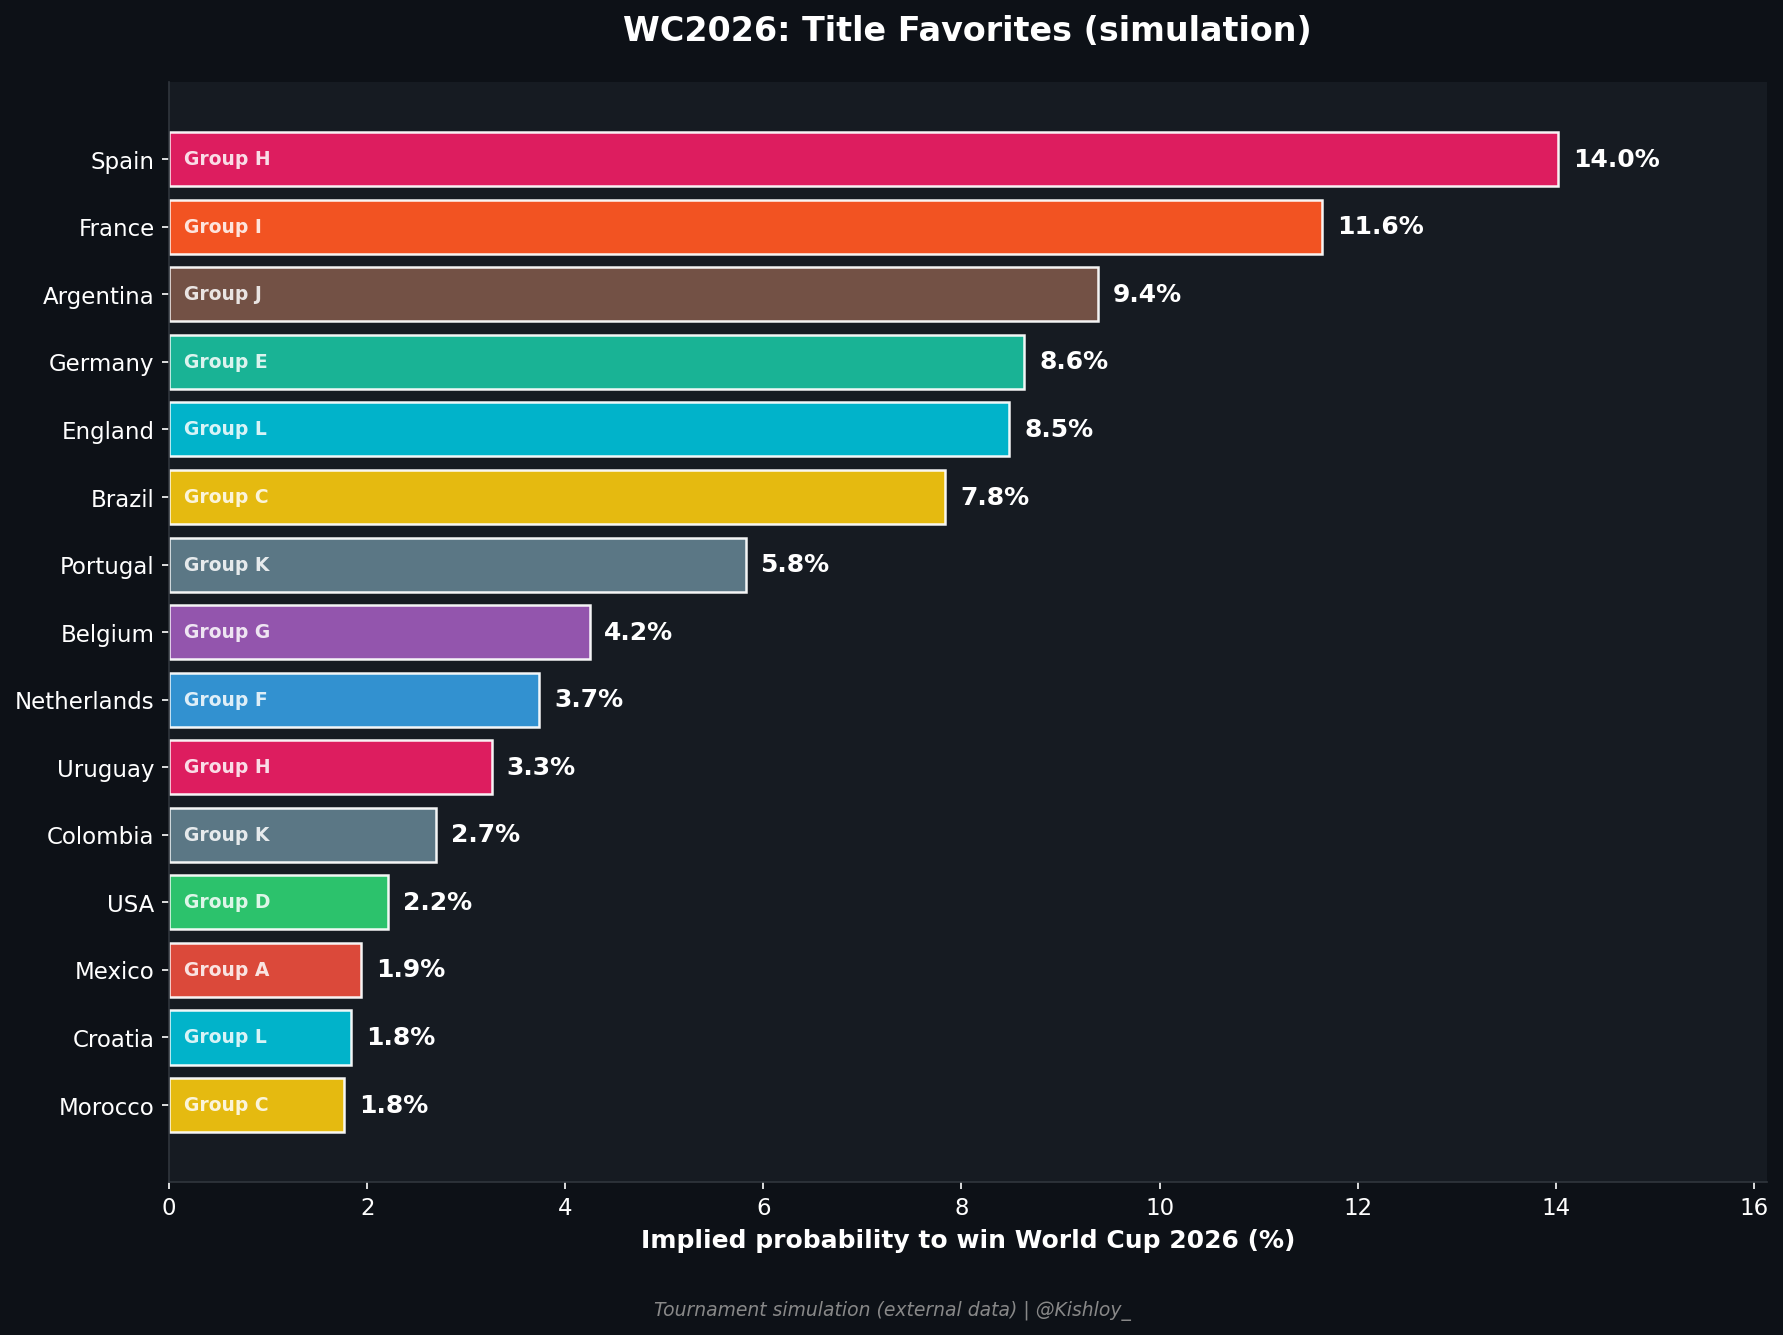

In [10]:
fav=sim_df.nlargest(15,'win_prob').sort_values('win_prob')
fig,ax=plt.subplots(figsize=(12,9));fig.patch.set_facecolor(BG);ax.set_facecolor(PANEL)
bars=ax.barh(fav['team'],fav['win_prob']*100,color=[GROUP_COLORS[g] for g in fav['group']],edgecolor='white',linewidth=1.2,alpha=0.95)
for bar,val,grp in zip(bars,fav['win_prob']*100,fav['group']):
    ax.text(val+0.15,bar.get_y()+bar.get_height()/2,f'{val:.1f}%',va='center',color='white',fontsize=12,fontweight='bold')
    ax.text(0.15,bar.get_y()+bar.get_height()/2,f'Group {grp}',va='center',color='white',alpha=0.85,fontsize=9,fontweight='bold')
ax.set_xlabel('Implied probability to win World Cup 2026 (%)',color='white',fontsize=12,fontweight='bold')
ax.set_title('WC2026: Title Favorites (simulation)',color='white',fontsize=16,fontweight='bold',pad=20)
ax.tick_params(colors='white',labelsize=11)
for sp in ax.spines.values():sp.set_color(GRID)
ax.set_xlim(0,(fav['win_prob']*100).max()*1.15)
fig.text(0.5,0.02,CREDIT_SIM,ha='center',color=MUTED,fontsize=9,style='italic')
plt.tight_layout(rect=[0,0.05,1,1]);plt.savefig('m4_favorites.png',dpi=200,bbox_inches='tight',facecolor=BG);plt.show()

### 2b. Power ranking by Supremacy

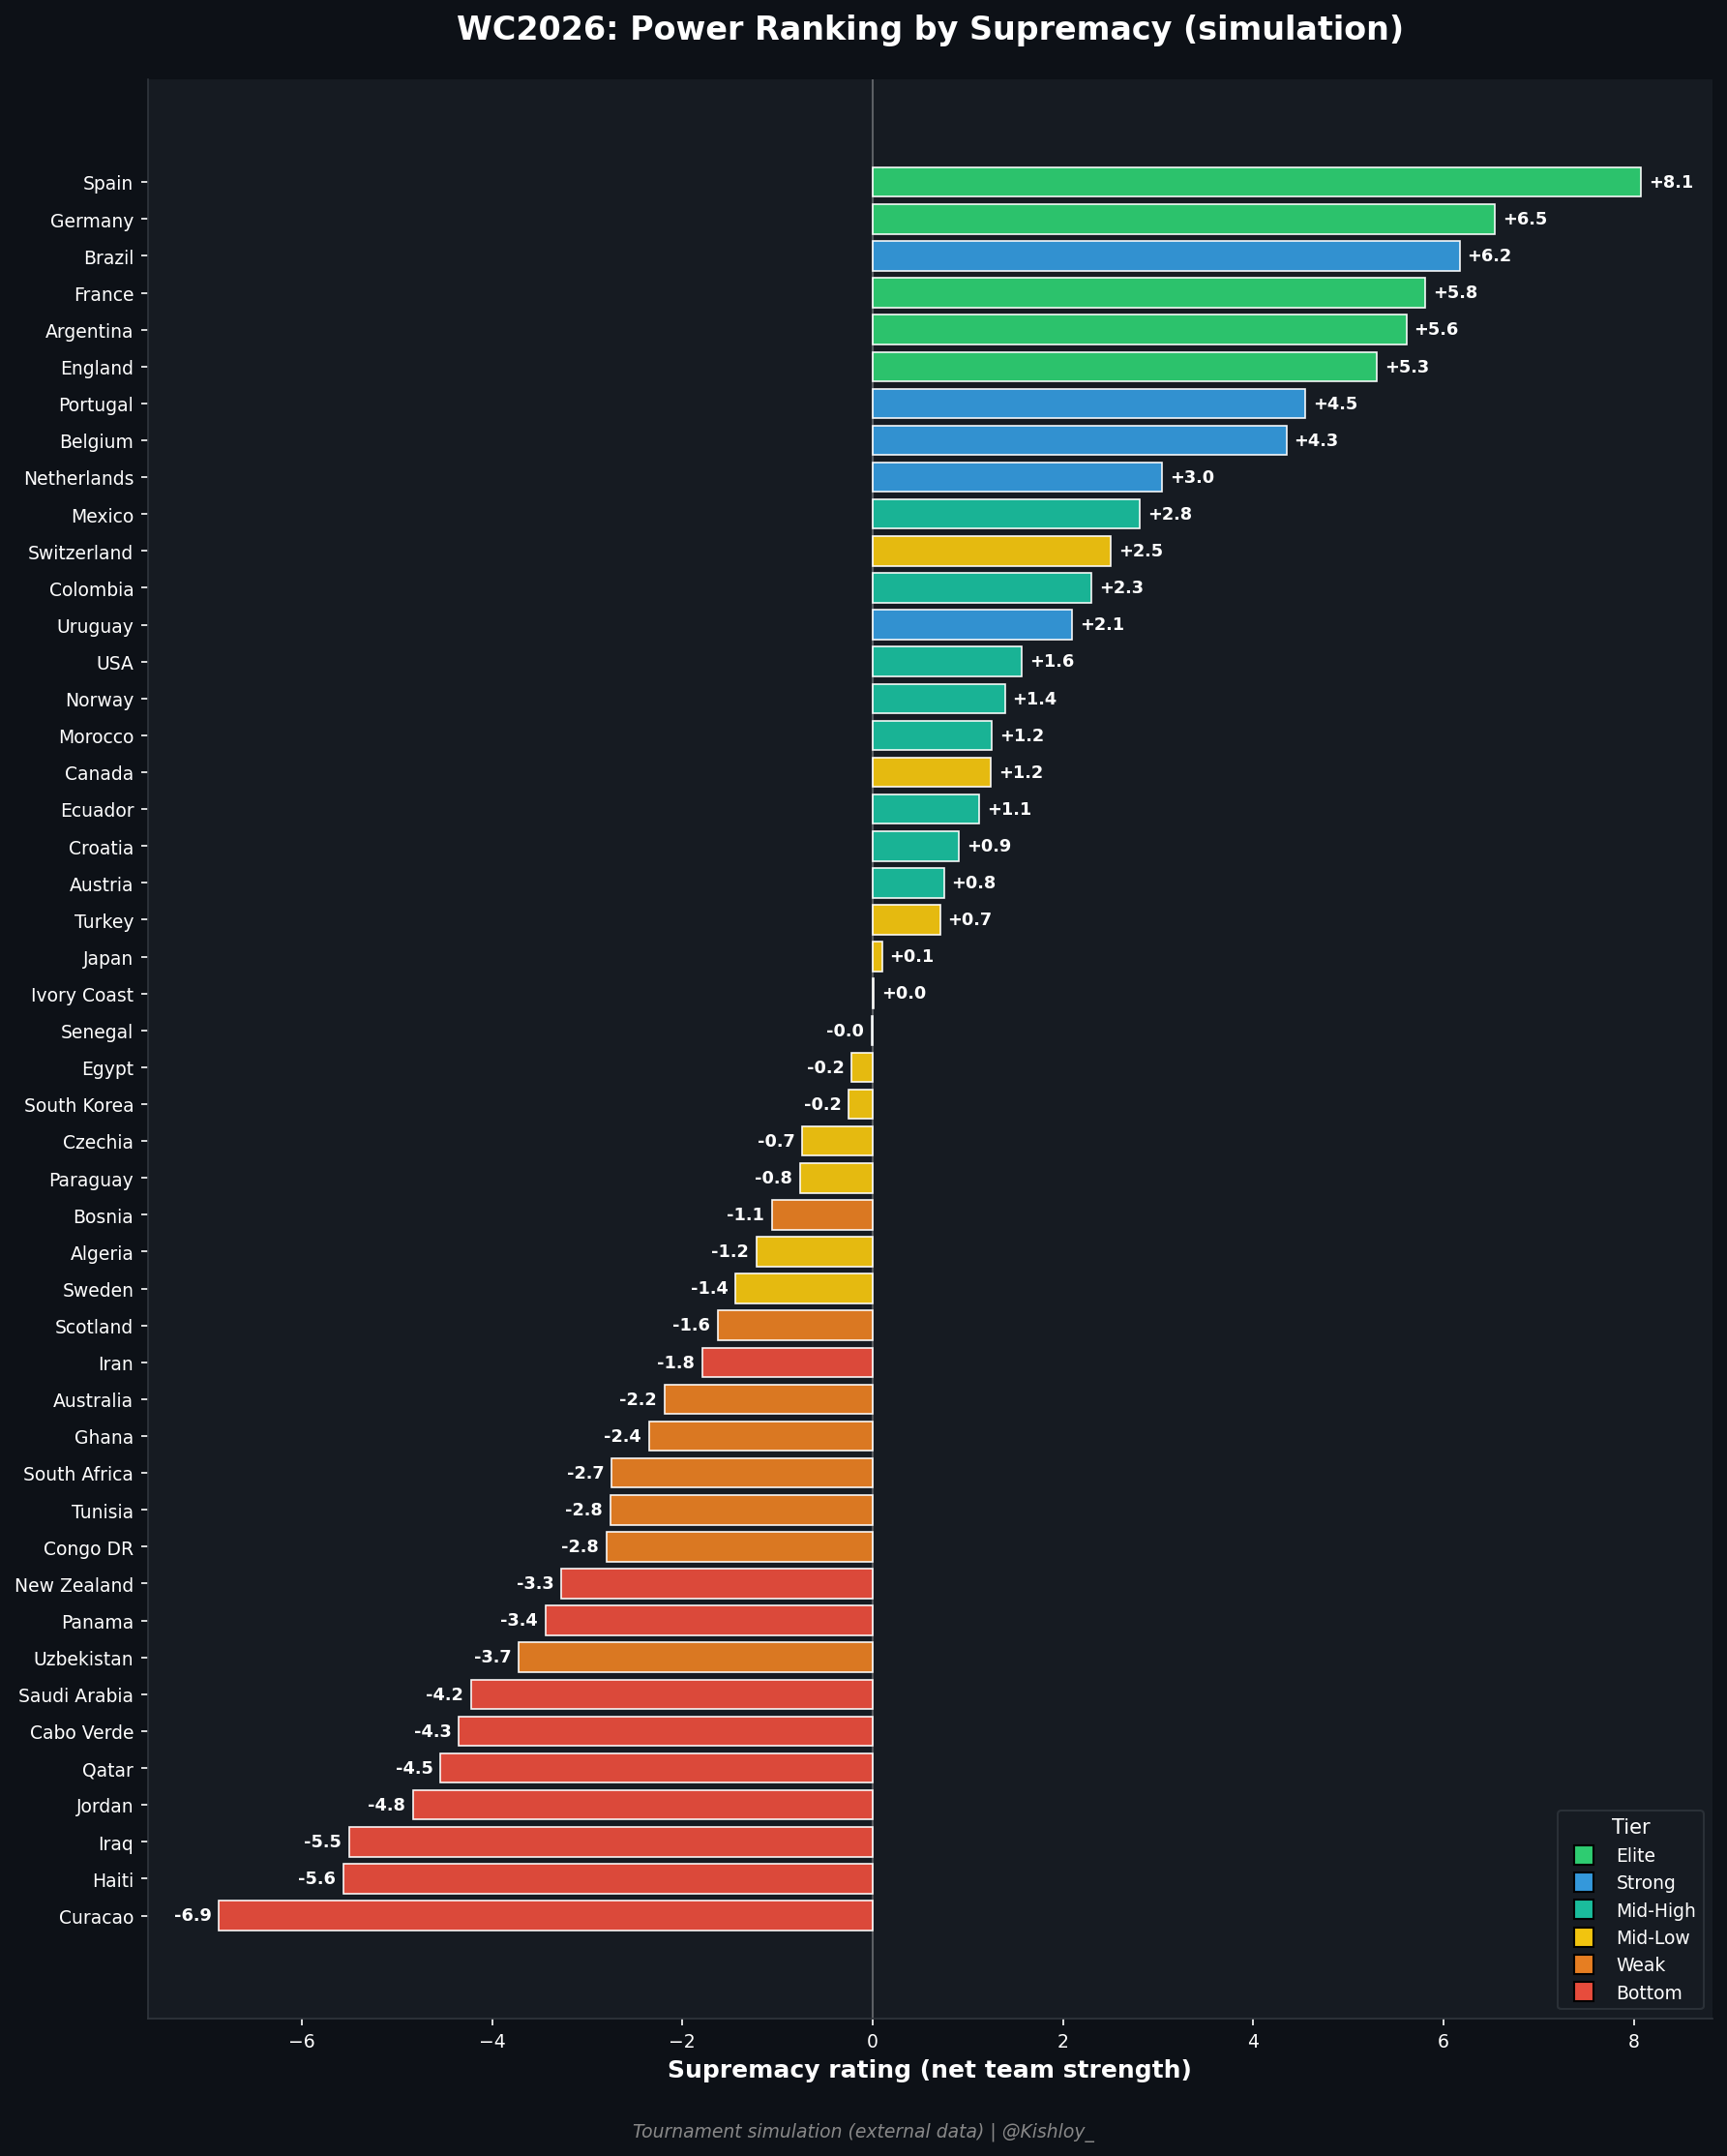

In [11]:
ps=sim_df.sort_values('supremacy')
fig,ax=plt.subplots(figsize=(12,15));fig.patch.set_facecolor(BG);ax.set_facecolor(PANEL)
bars=ax.barh(ps['team'],ps['supremacy'],color=[TIER_COLORS[t] for t in ps['tier']],edgecolor='white',linewidth=0.8,alpha=0.95)
for bar,val in zip(bars,ps['supremacy']):
    ax.text(val+(0.08 if val>=0 else -0.08),bar.get_y()+bar.get_height()/2,f'{val:+.1f}',va='center',ha='left' if val>=0 else 'right',color='white',fontsize=8.5,fontweight='bold')
ax.axvline(0,color='white',alpha=0.3,lw=1)
ax.set_xlabel('Supremacy rating (net team strength)',color='white',fontsize=12,fontweight='bold')
ax.set_title('WC2026: Power Ranking by Supremacy (simulation)',color='white',fontsize=16,fontweight='bold',pad=20)
ax.tick_params(colors='white',labelsize=9)
for sp in ax.spines.values():sp.set_color(GRID)
h=[Line2D([0],[0],marker='s',color='none',markerfacecolor=TIER_COLORS[t],markersize=10,label=t) for t in TIER_ORDER]
lg=ax.legend(handles=h,loc='lower right',facecolor=PANEL,labelcolor='white',edgecolor=GRID,fontsize=9,title='Tier')
lg.get_title().set_color('white')
fig.text(0.5,0.015,CREDIT_SIM,ha='center',color=MUTED,fontsize=9,style='italic')
plt.tight_layout(rect=[0,0.03,1,1]);plt.savefig('m5_supremacy.png',dpi=200,bbox_inches='tight',facecolor=BG);plt.show()

### 2c. Group of death

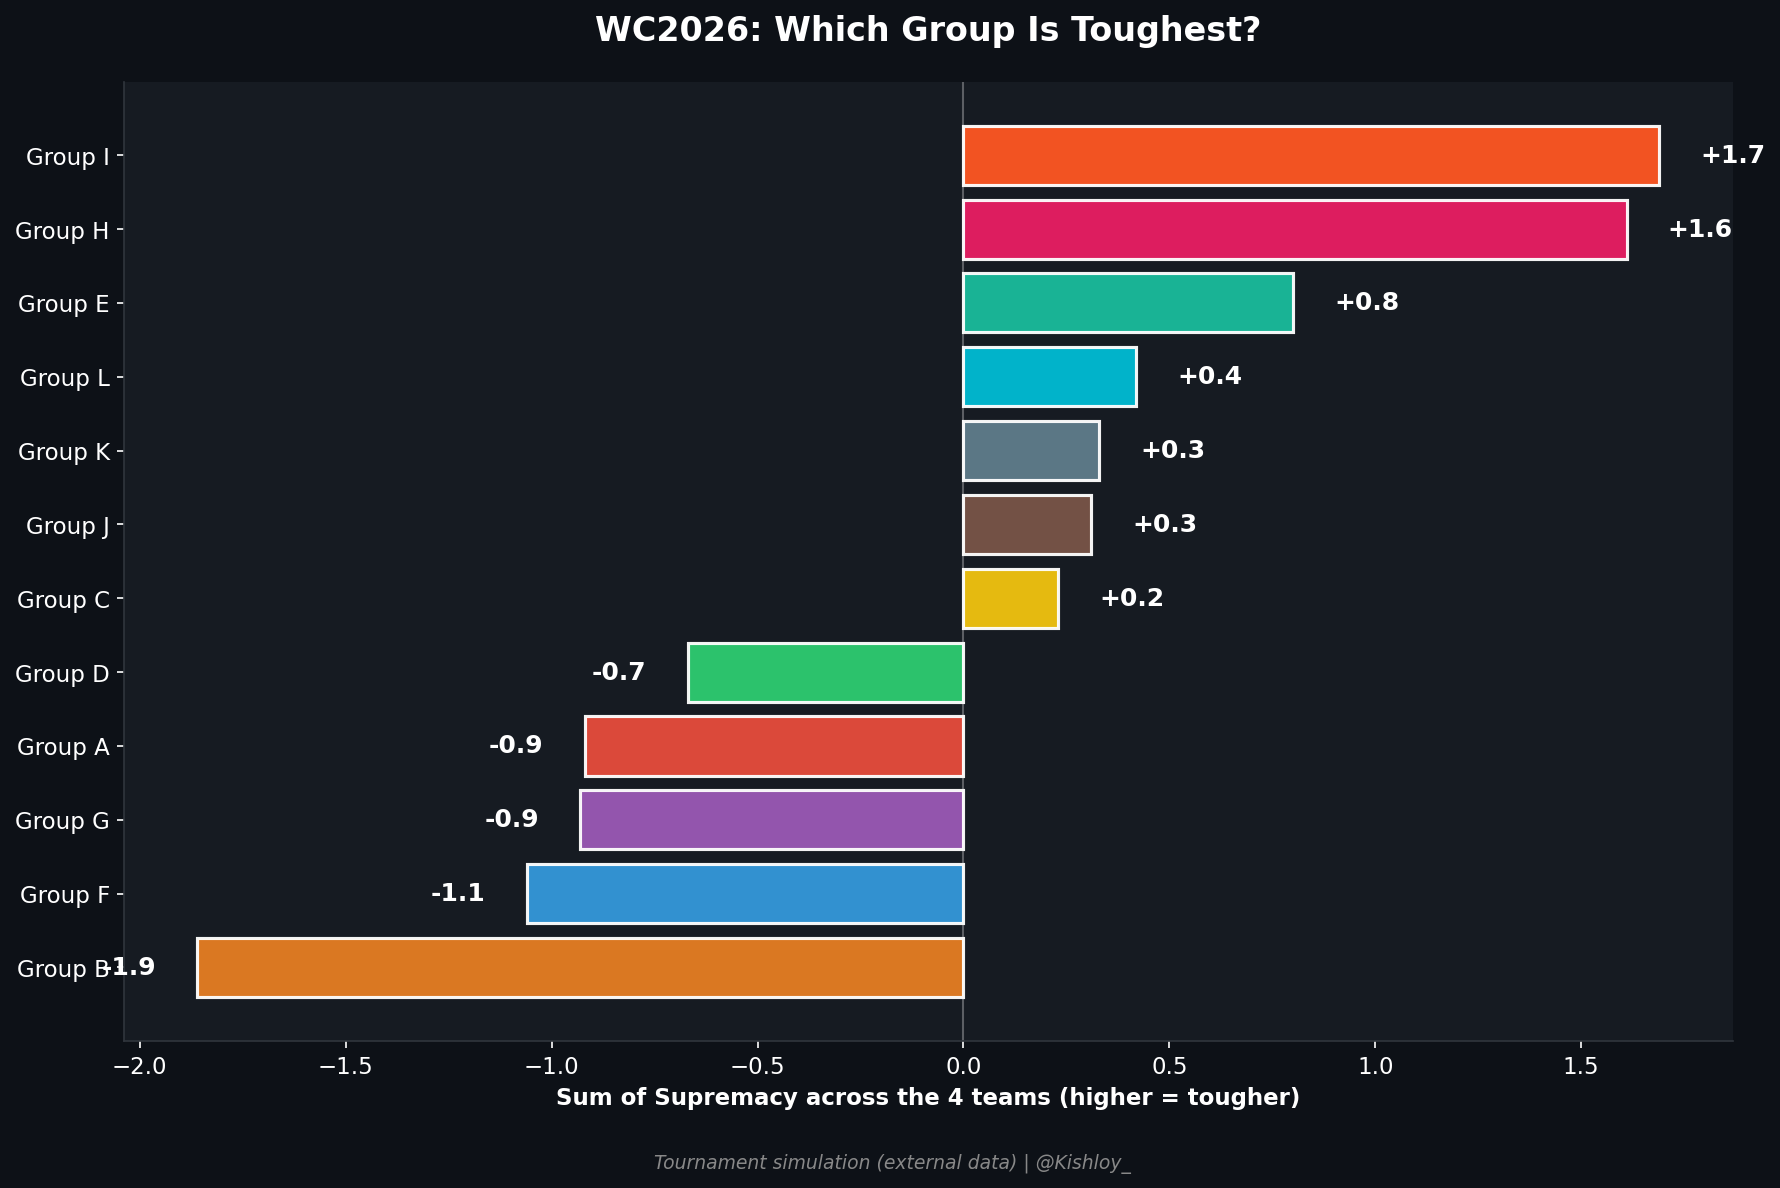

In [12]:
gs=sim_df.groupby('group',observed=True)['supremacy'].sum().sort_values()
fig,ax=plt.subplots(figsize=(12,8));fig.patch.set_facecolor(BG);ax.set_facecolor(PANEL)
bars=ax.barh([f'Group {g}' for g in gs.index],gs.values,color=[GROUP_COLORS[g] for g in gs.index],edgecolor='white',linewidth=1.5,alpha=0.95)
for bar,val in zip(bars,gs.values):
    ax.text(val+(0.1 if val>=0 else -0.1),bar.get_y()+bar.get_height()/2,f'{val:+.1f}',va='center',ha='left' if val>=0 else 'right',color='white',fontsize=12,fontweight='bold')
ax.axvline(0,color='white',alpha=0.3,lw=1)
ax.set_xlabel('Sum of Supremacy across the 4 teams (higher = tougher)',color='white',fontsize=11,fontweight='bold')
ax.set_title('WC2026: Which Group Is Toughest?',color='white',fontsize=16,fontweight='bold',pad=20)
ax.tick_params(colors='white',labelsize=11)
for sp in ax.spines.values():sp.set_color(GRID)
fig.text(0.5,0.02,CREDIT_SIM,ha='center',color=MUTED,fontsize=9,style='italic')
plt.tight_layout(rect=[0,0.05,1,1]);plt.savefig('m6_group_death.png',dpi=200,bbox_inches='tight',facecolor=BG);plt.show()

### 2d. Group finishing probabilities

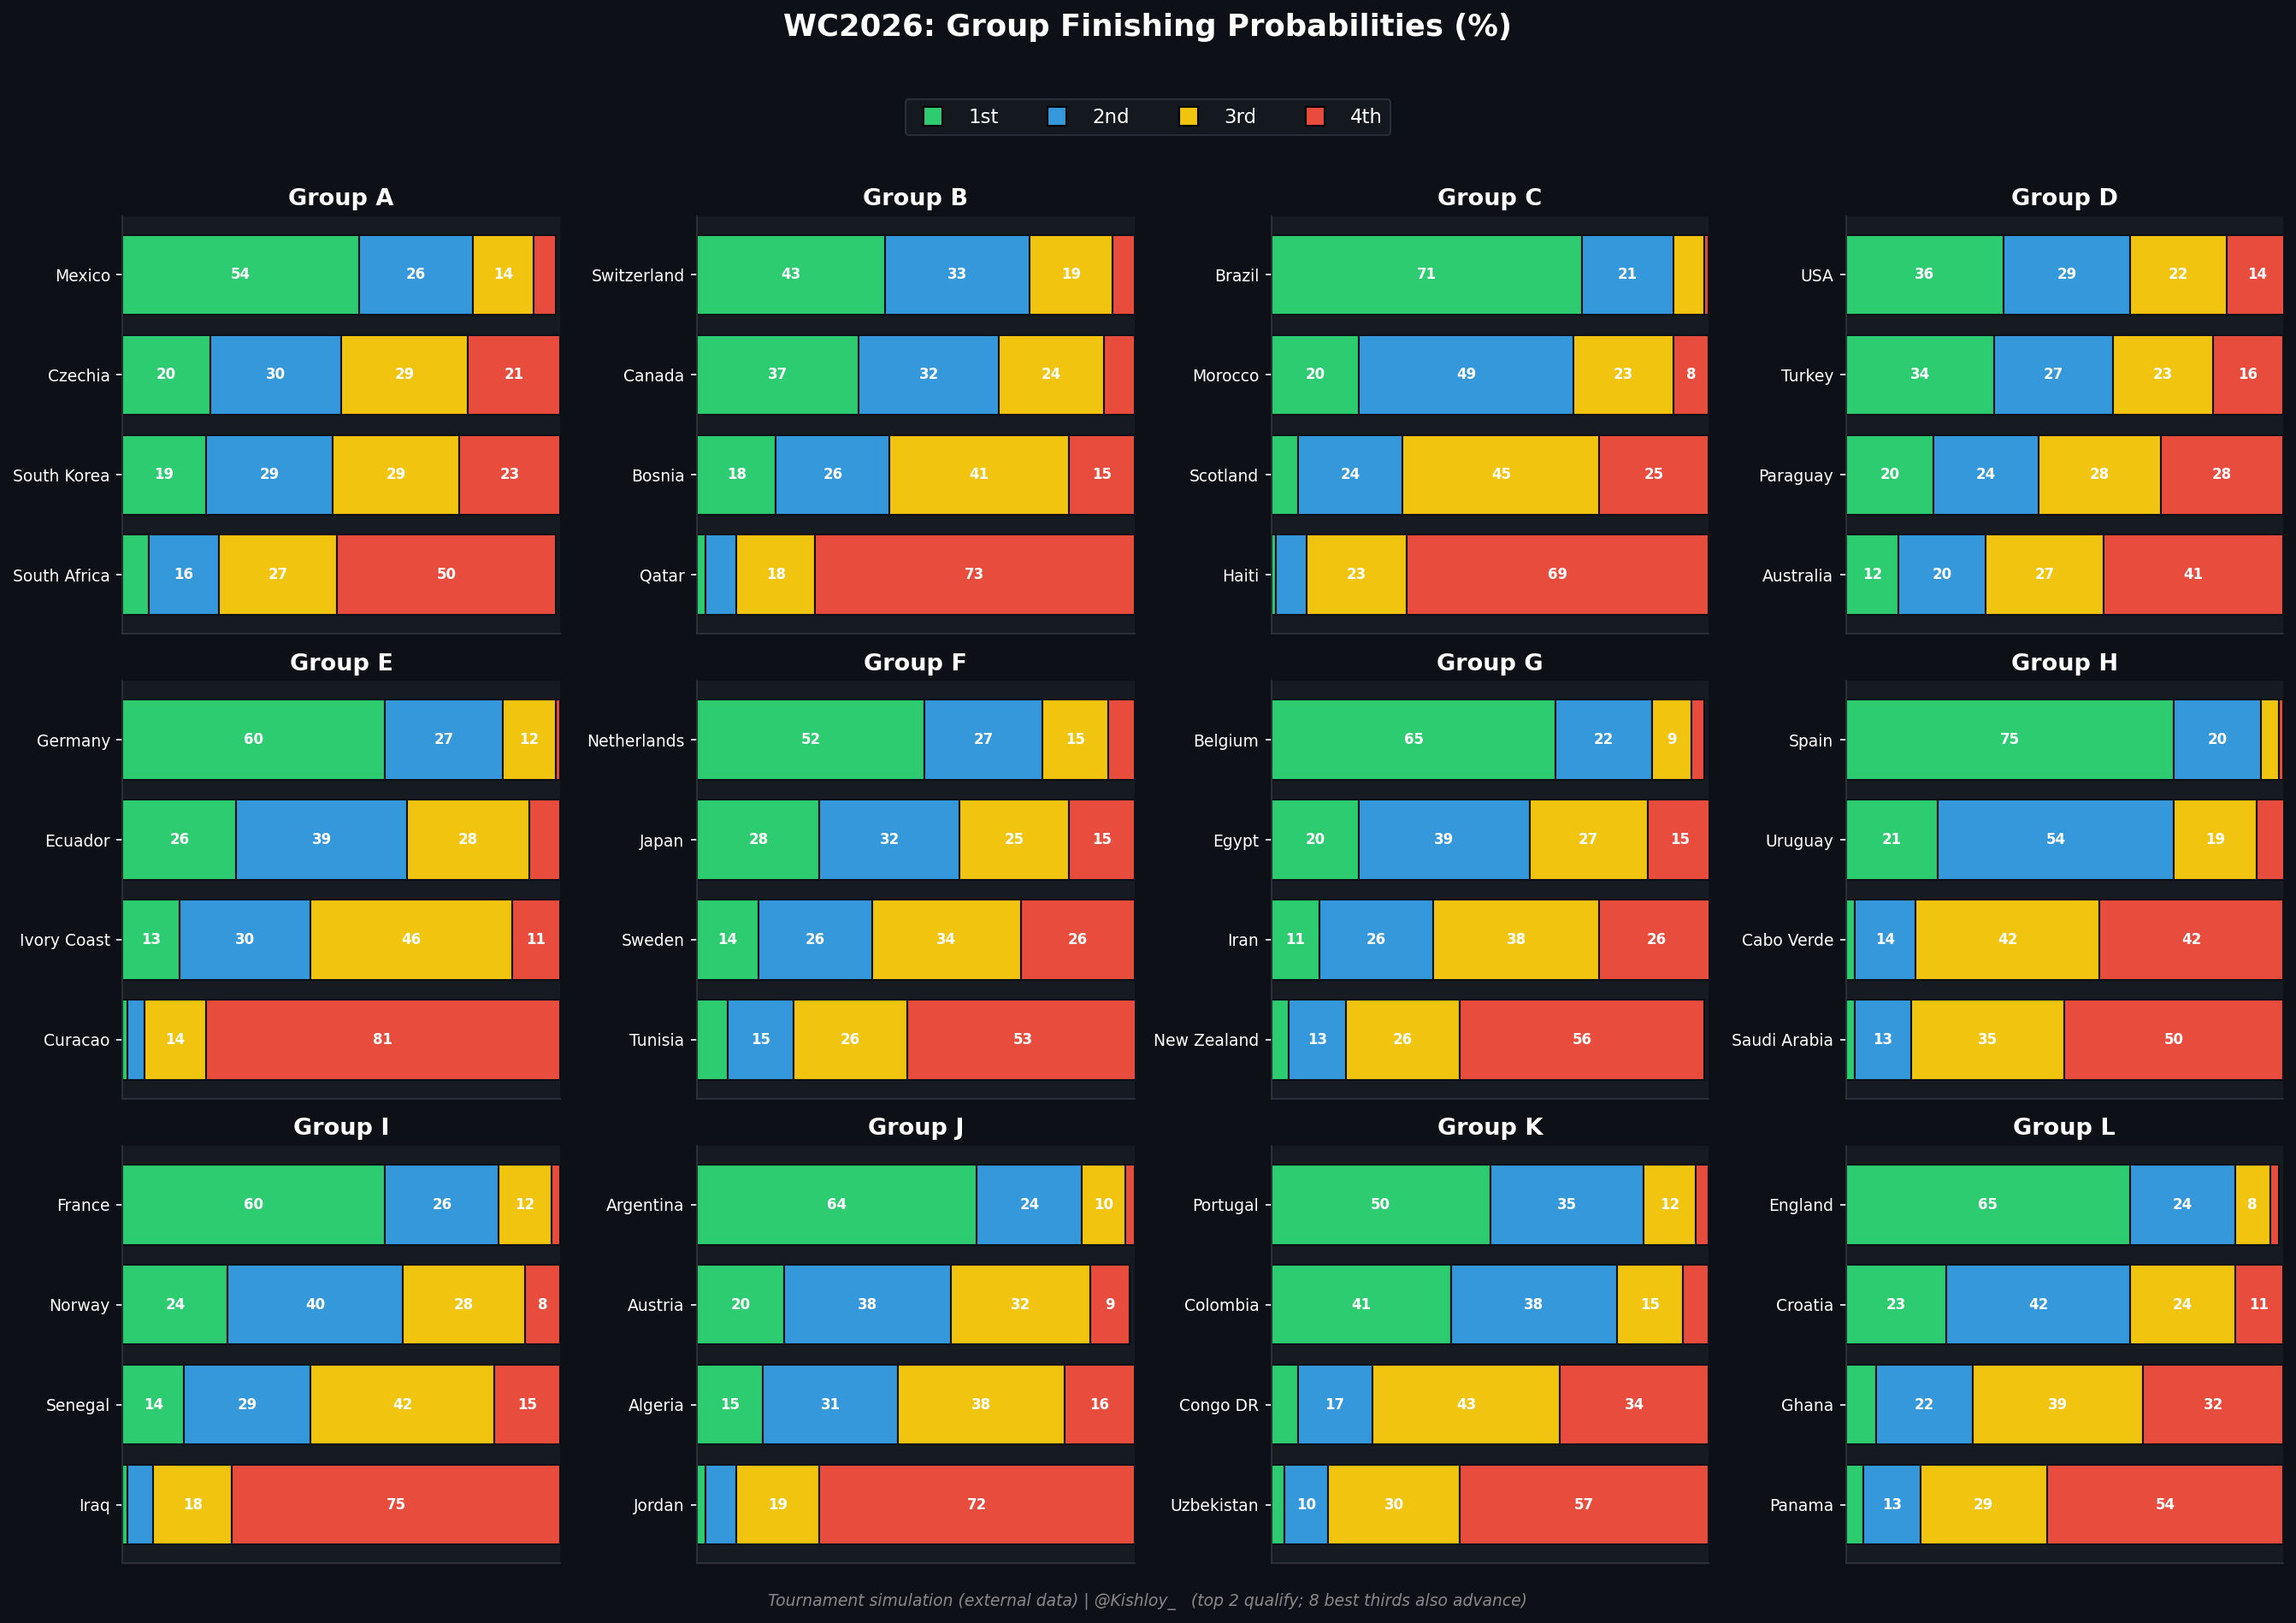

In [13]:
pc=['#2ecc71','#3498db','#f1c40f','#e74c3c'];pl=['1st','2nd','3rd','4th']
fig,axes=plt.subplots(3,4,figsize=(18,12));fig.patch.set_facecolor(BG)
for ax,g in zip(axes.flat,sorted(sim_df['group'].unique())):
    ax.set_facecolor(PANEL)
    sub=sim_df[sim_df['group']==g].sort_values(['p1','p2'],ascending=False)
    teams=sub['team'].tolist();P=sub[['p1','p2','p3','p4']].values*100;left=np.zeros(len(teams))
    for j in range(4):
        ax.barh(teams,P[:,j],left=left,color=pc[j],edgecolor=BG,linewidth=1)
        for i,(v,l) in enumerate(zip(P[:,j],left)):
            if v>=8: ax.text(l+v/2,i,f'{v:.0f}',va='center',ha='center',color='white',fontsize=8,fontweight='bold')
        left+=P[:,j]
    ax.set_title(f'Group {g}',color='white',fontsize=13,fontweight='bold')
    ax.set_xlim(0,100);ax.tick_params(colors='white',labelsize=9);ax.set_xticks([]);ax.invert_yaxis()
    for sp in ax.spines.values():sp.set_color(GRID)
h=[Line2D([0],[0],marker='s',color='none',markerfacecolor=pc[j],markersize=11,label=pl[j]) for j in range(4)]
fig.legend(handles=h,loc='upper center',ncol=4,facecolor=PANEL,labelcolor='white',edgecolor=GRID,fontsize=11,bbox_to_anchor=(0.5,0.99))
fig.suptitle('WC2026: Group Finishing Probabilities (%)',color='white',fontsize=17,fontweight='bold',y=1.04)
fig.text(0.5,0.005,CREDIT_SIM+'   (top 2 qualify; 8 best thirds also advance)',ha='center',color=MUTED,fontsize=9,style='italic')
plt.tight_layout(rect=[0,0.02,1,0.97]);plt.savefig('m7_qualification.png',dpi=200,bbox_inches='tight',facecolor=BG);plt.show()

### 2e. Confederation strength

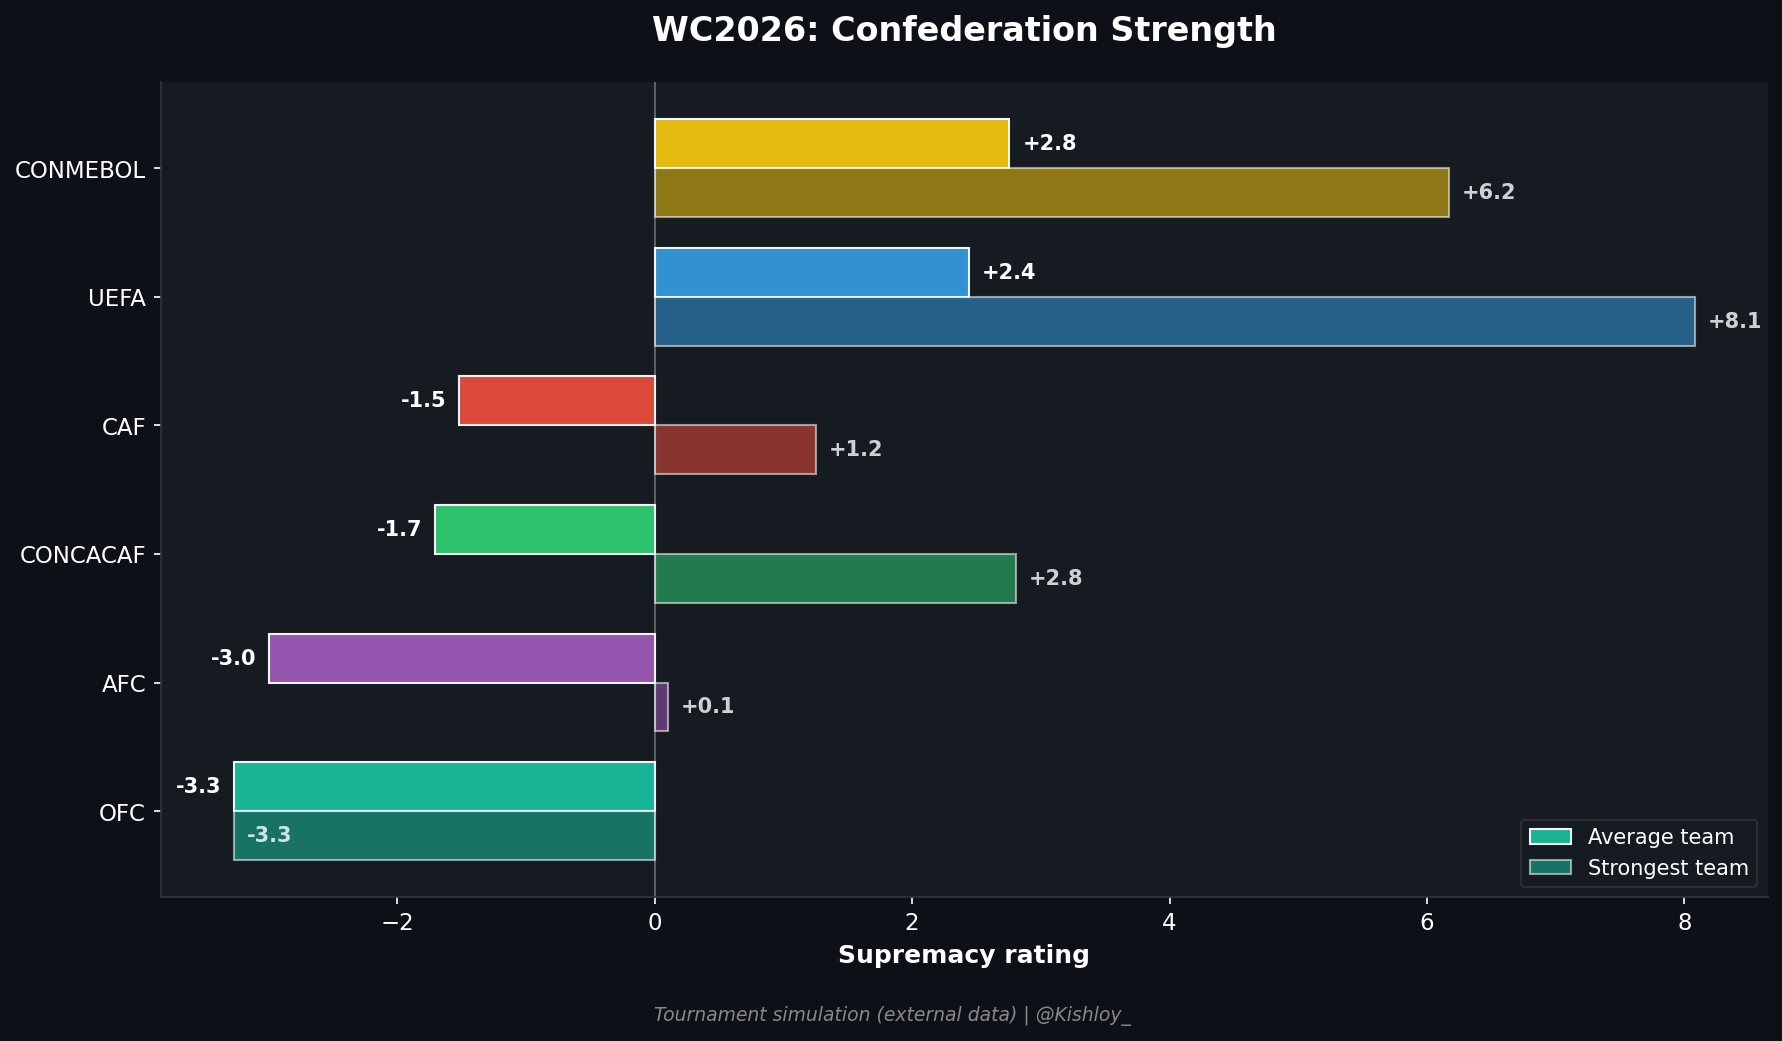

In [14]:
ca=sim_df.groupby('conf')['supremacy'].agg(['mean','max']).sort_values('mean')
fig,ax=plt.subplots(figsize=(12,7));fig.patch.set_facecolor(BG);ax.set_facecolor(PANEL)
y=np.arange(len(ca));h=0.38
ax.barh(y+h/2,ca['mean'],height=h,color=[CONF_COLORS[c] for c in ca.index],edgecolor='white',linewidth=1,alpha=0.95,label='Average team')
ax.barh(y-h/2,ca['max'],height=h,color=[CONF_COLORS[c] for c in ca.index],edgecolor='white',linewidth=1,alpha=0.55,label='Strongest team')
ax.axvline(0,color='white',alpha=0.3,lw=1);ax.set_yticks(y);ax.set_yticklabels(ca.index)
for i,(m,mx) in enumerate(zip(ca['mean'],ca['max'])):
    ax.text(m+(0.1 if m>=0 else -0.1),i+h/2,f'{m:+.1f}',va='center',ha='left' if m>=0 else 'right',color='white',fontsize=10,fontweight='bold')
    ax.text(mx+0.1,i-h/2,f'{mx:+.1f}',va='center',color='white',alpha=0.8,fontsize=10,fontweight='bold')
ax.set_xlabel('Supremacy rating',color='white',fontsize=12,fontweight='bold')
ax.set_title('WC2026: Confederation Strength',color='white',fontsize=16,fontweight='bold',pad=20)
ax.tick_params(colors='white',labelsize=11)
for sp in ax.spines.values():sp.set_color(GRID)
ax.legend(facecolor=PANEL,labelcolor='white',edgecolor=GRID,fontsize=10,loc='lower right')
fig.text(0.5,0.02,CREDIT_SIM,ha='center',color=MUTED,fontsize=9,style='italic')
plt.tight_layout(rect=[0,0.05,1,1]);plt.savefig('m8_confederation.png',dpi=200,bbox_inches='tight',facecolor=BG);plt.show()

## Part 3: The bridge, performance vs projection

Now the two datasets meet. The merge keeps only the 46 teams that have both opponent-adjusted xG and simulation output, since Scotland and Ivory Coast have no match data.

In [15]:
m = adj.merge(sim_df, on=['team','group'], how='inner')
m['obs_net'] = (m['adj_xg'] - m['adj_xga']).round(2)        # observed net, from qualifying xG
m['draw_shift'] = (m['sim_xg'] - m['adj_xg']).round(2)       # projection minus observed attack
print(f"{len(m)} teams in both datasets")
m.sort_values('supremacy',ascending=False).head(10)[['team','group','adj_xg','sim_xg','draw_shift','obs_net','supremacy','win_prob']]

46 teams in both datasets


,team,group,adj_xg,sim_xg,draw_shift,obs_net,supremacy,win_prob
38,Spain,H,2.45,2.49,0.04,1.82,8.08,0.140252
18,Germany,E,2.09,2.40,0.31,1.48,6.54,0.086356
6,Brazil,C,1.52,1.55,0.03,0.81,6.17,0.078370
17,France,I,2.59,1.98,-0.61,2.07,5.81,0.116414
1,Argentina,J,1.66,1.99,0.33,1.11,5.61,0.093809
16,England,L,1.84,1.91,0.07,1.32,5.30,0.084818
32,Portugal,K,2.55,1.92,-0.63,2.01,4.55,0.058207
4,Belgium,G,2.05,1.87,-0.18,1.34,4.35,0.042445
27,Netherlands,F,2.17,1.68,-0.49,1.52,3.04,0.037355
25,Mexico,A,1.55,1.55,0.00,0.72,2.81,0.019399


### 3a. Is the sim backed by the underlying numbers?

X axis is observed net xG from qualifying (qualifying data). Y axis is the simulation's Supremacy rating. Teams on the trend line are rated by the sim exactly as their qualifying xG suggests. Above the line, the sim rates them higher than the underlying numbers (reputation or an easy path). Below, the sim is harsher than the xG.

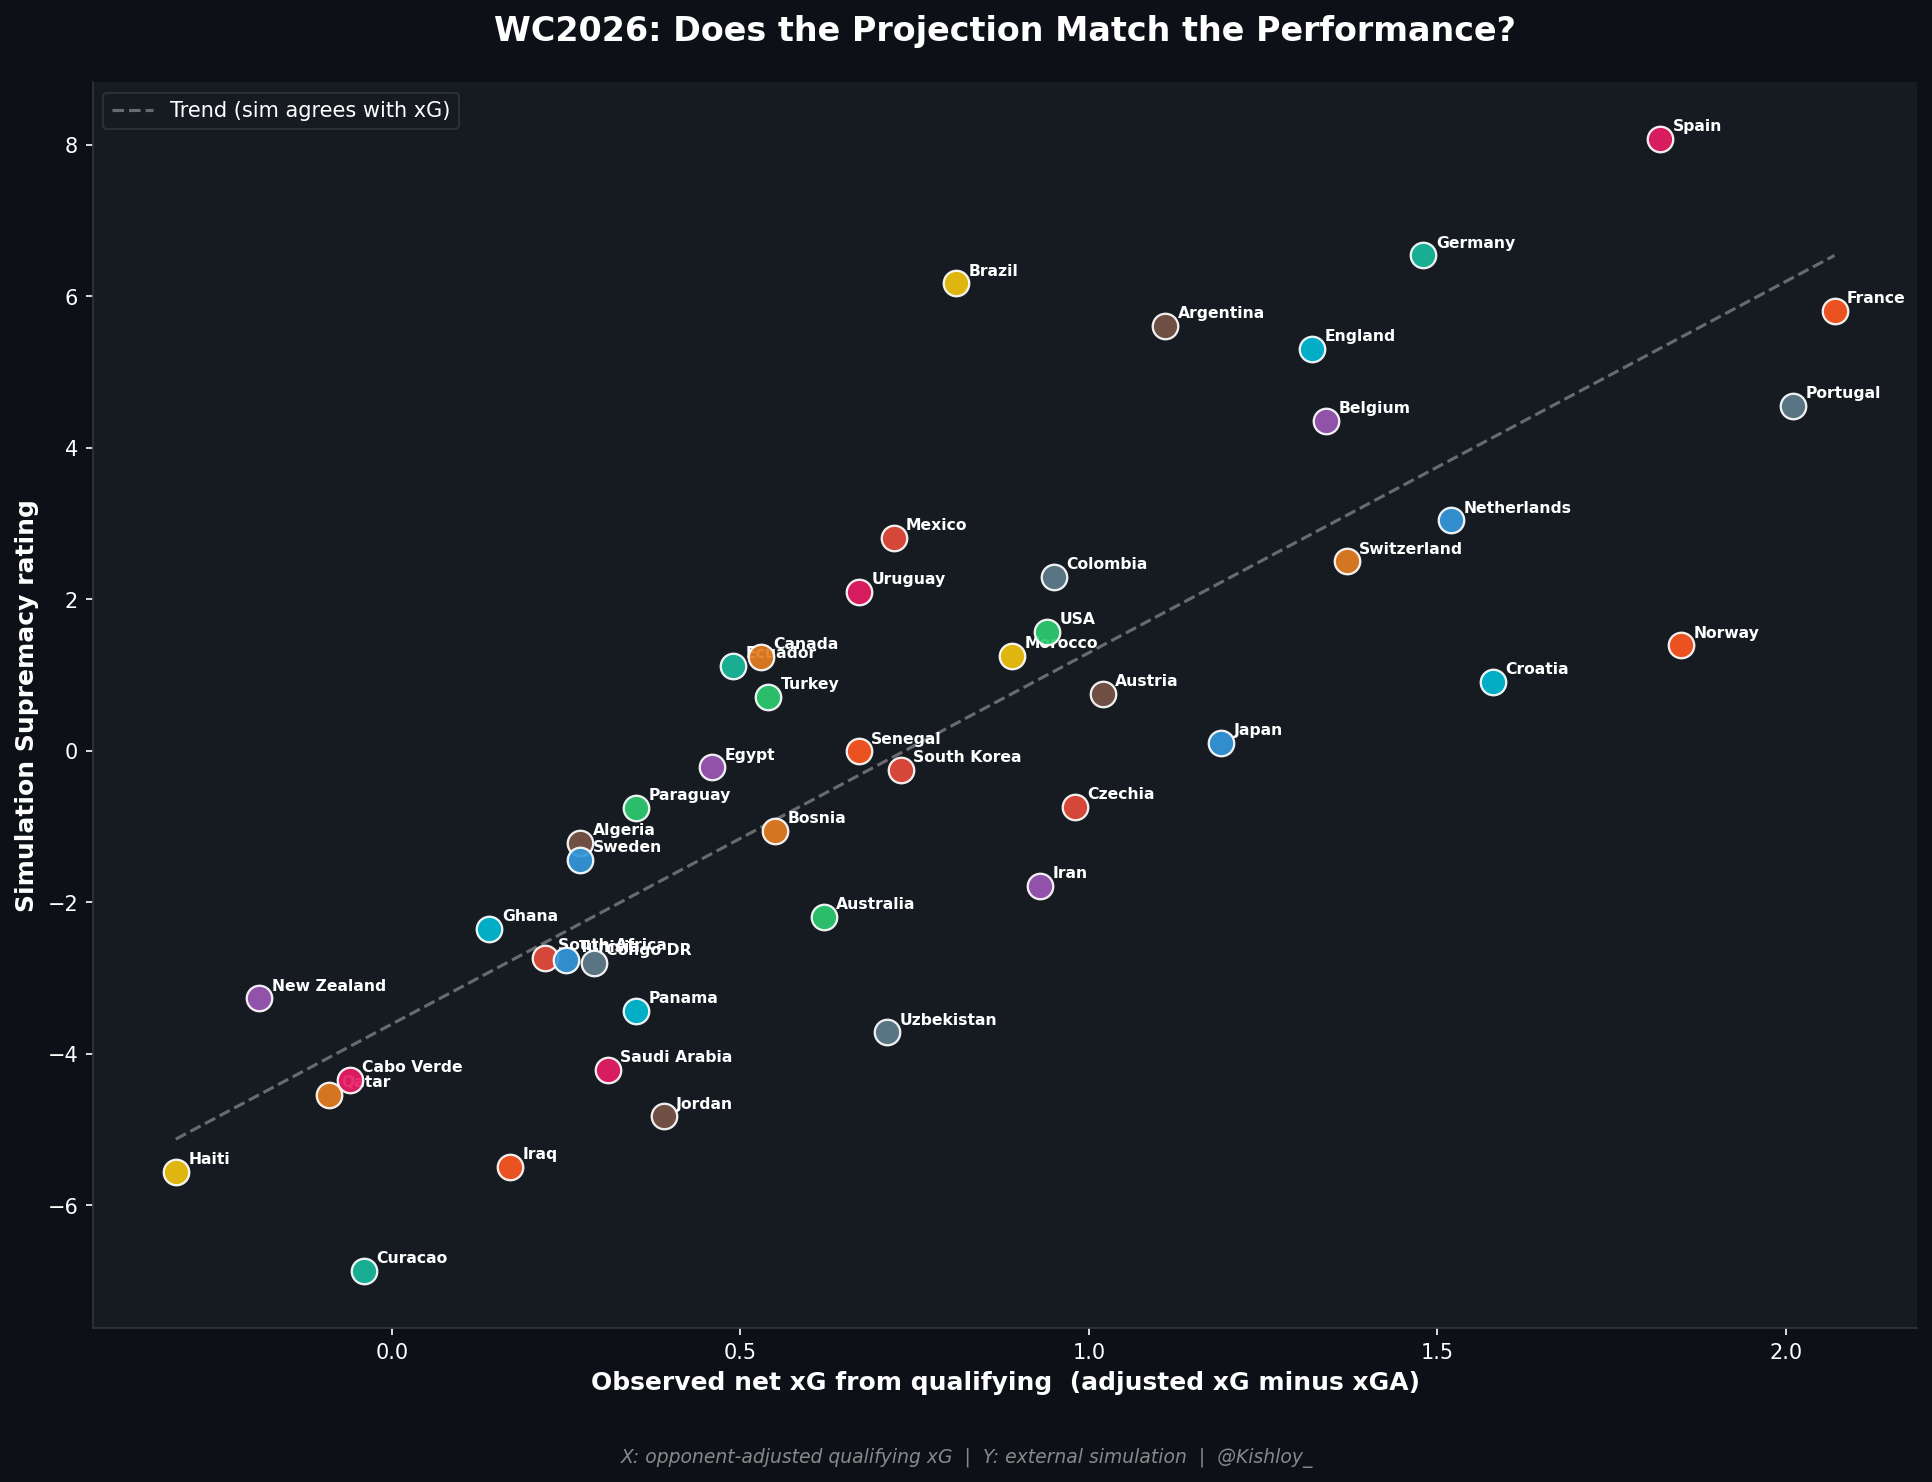

In [16]:
fig,ax=plt.subplots(figsize=(13,10));fig.patch.set_facecolor(BG);ax.set_facecolor(PANEL)
x=m['obs_net'].values;yv=m['supremacy'].values
b,a=np.polyfit(x,yv,1);xs=np.linspace(x.min(),x.max(),50)
ax.plot(xs,b*xs+a,color='white',alpha=0.35,ls='--',lw=1.5,zorder=2,label='Trend (sim agrees with xG)')
resid=yv-(b*x+a)
for _,r in m.iterrows():
    rr=r['supremacy']-(b*r['obs_net']+a)
    ax.scatter(r['obs_net'],r['supremacy'],color=GROUP_COLORS[r['group']],s=150,zorder=5,alpha=0.92,edgecolors='white',linewidth=1.1)
    ax.annotate(r['team'],(r['obs_net'],r['supremacy']),fontsize=7.5,color='white',xytext=(6,4),textcoords='offset points',fontweight='bold')
ax.set_xlabel('Observed net xG from qualifying  (adjusted xG minus xGA)',color='white',fontsize=12,fontweight='bold')
ax.set_ylabel('Simulation Supremacy rating',color='white',fontsize=12,fontweight='bold')
ax.set_title('WC2026: Does the Projection Match the Performance?',color='white',fontsize=16,fontweight='bold',pad=20)
ax.tick_params(colors='white',labelsize=10)
for sp in ax.spines.values():sp.set_color(GRID)
ax.legend(facecolor=PANEL,labelcolor='white',edgecolor=GRID,fontsize=10,loc='upper left')
fig.text(0.5,0.02,'X: opponent-adjusted qualifying xG  |  Y: external simulation  |  @Kishloy_',ha='center',color=MUTED,fontsize=9,style='italic')
plt.tight_layout(rect=[0,0.05,1,1]);plt.savefig('m9_bridge_scatter.png',dpi=200,bbox_inches='tight',facecolor=BG);plt.show()

### 3b. The draw effect

For the 16 strongest teams, observed adjusted xG (what they did in qualifying) against the simulation's projected xG for the tournament. A rightward jump means an easier draw is expected to inflate output. A leftward drop means a tougher draw, or that the qualifying number was padded against weak opponents.

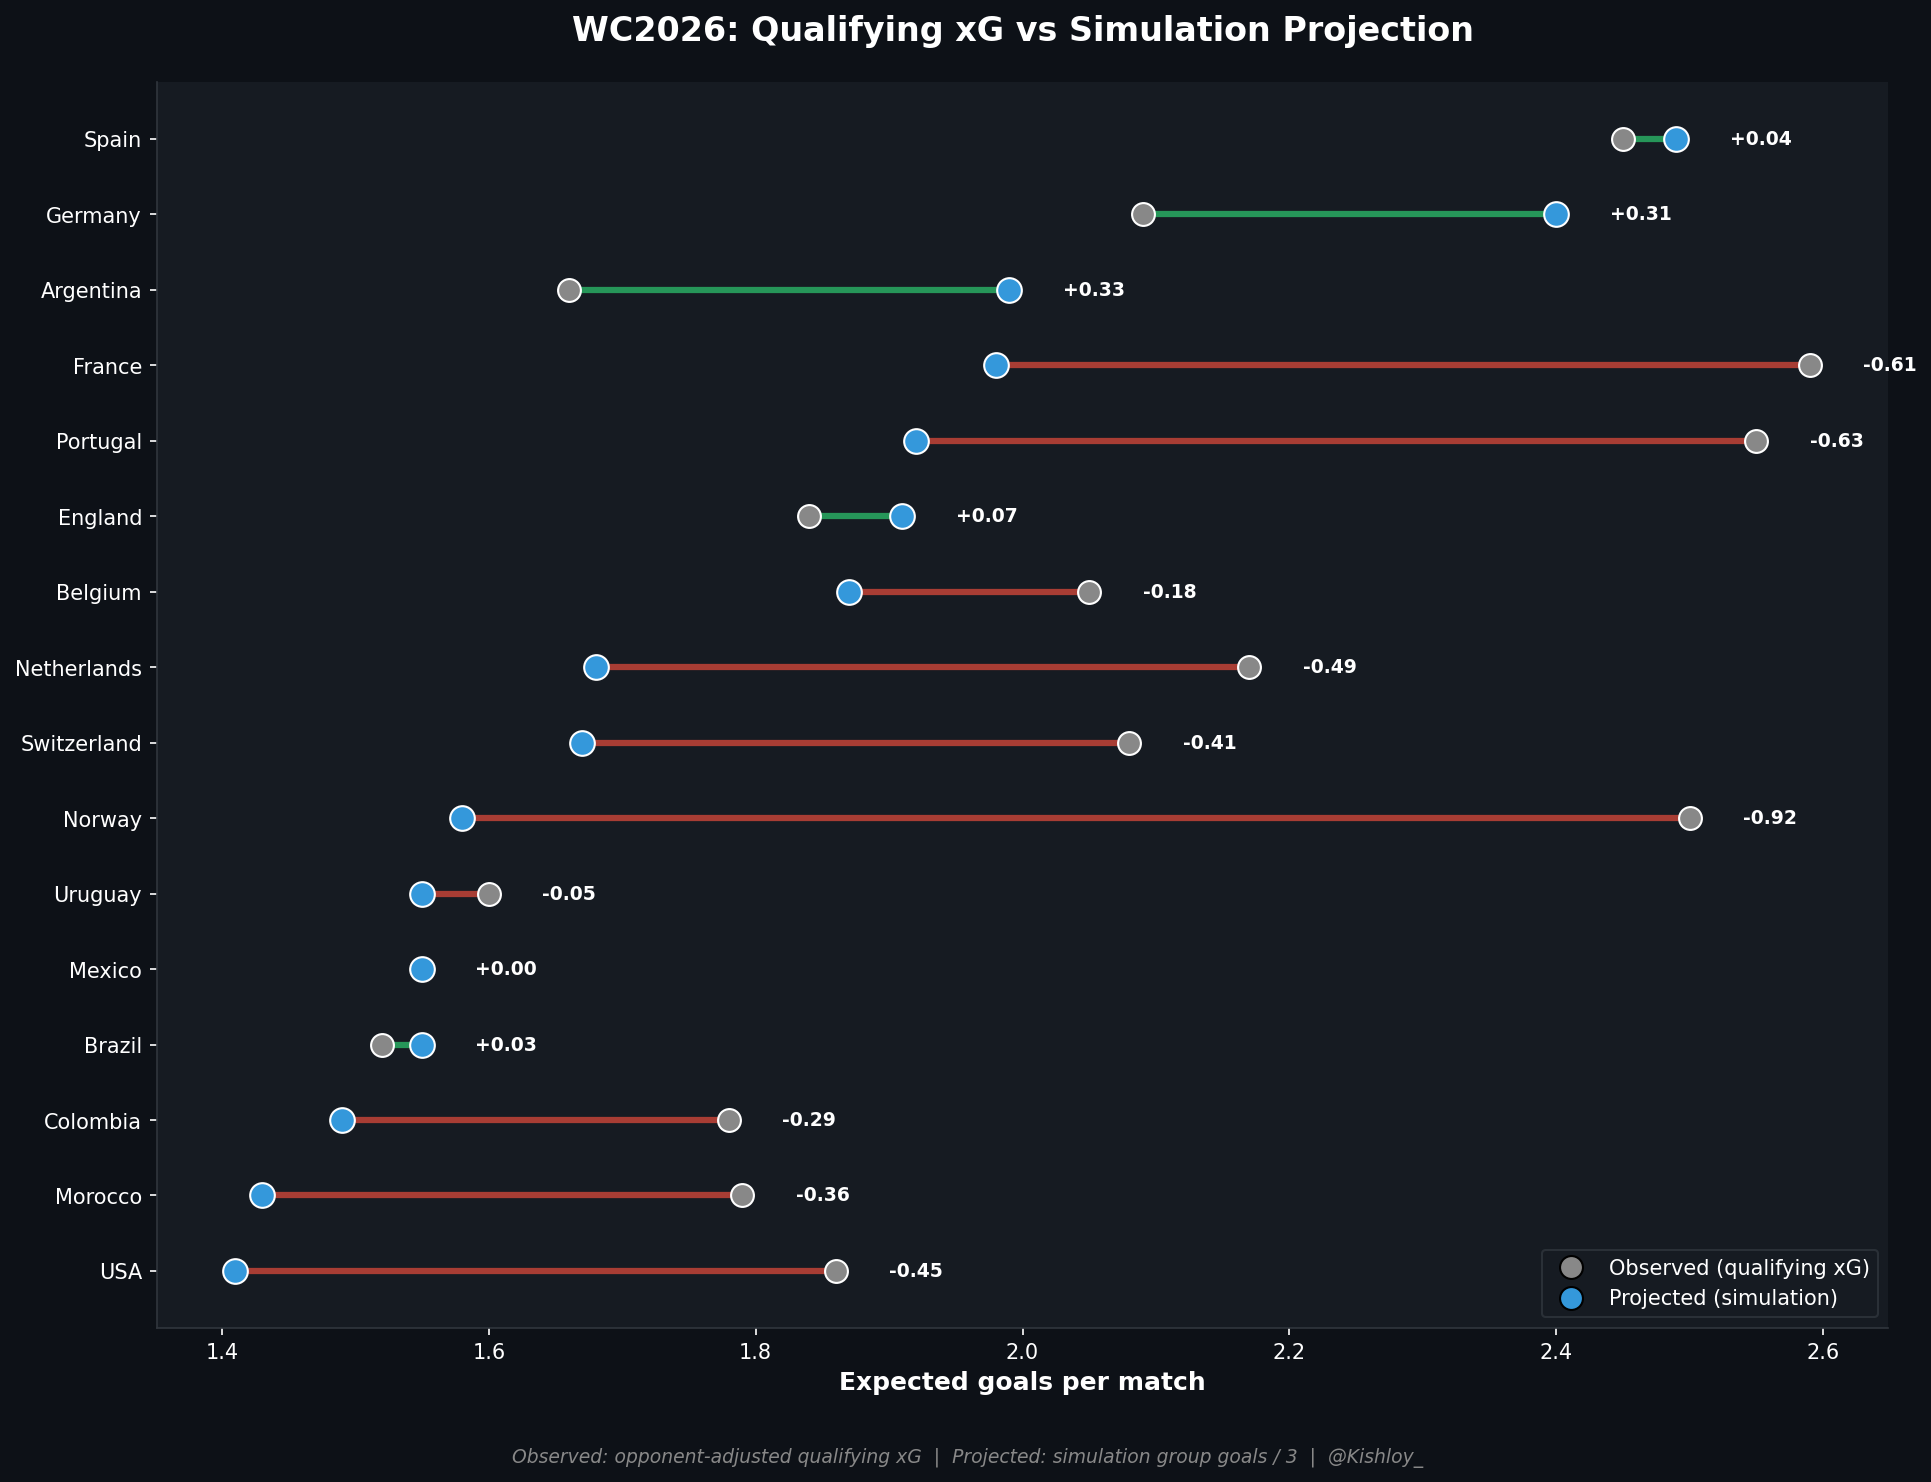

In [17]:
top=m.nlargest(16,'supremacy').sort_values('sim_xg')
fig,ax=plt.subplots(figsize=(13,10));fig.patch.set_facecolor(BG);ax.set_facecolor(PANEL)
yp=np.arange(len(top))
for i,(_,r) in enumerate(top.iterrows()):
    up = r['sim_xg']>=r['adj_xg']
    ax.plot([r['adj_xg'],r['sim_xg']],[i,i],color='#2ecc71' if up else '#e74c3c',lw=3,alpha=0.7,zorder=2)
    ax.scatter(r['adj_xg'],i,color=MUTED,s=120,zorder=4,edgecolors='white',linewidth=1)
    ax.scatter(r['sim_xg'],i,color='#3498db',s=140,zorder=5,edgecolors='white',linewidth=1)
    ax.text(max(r['adj_xg'],r['sim_xg'])+0.04,i,f"{r['draw_shift']:+.2f}",va='center',color='white',fontsize=9,fontweight='bold')
ax.set_yticks(yp);ax.set_yticklabels(top['team'],color='white')
ax.set_xlabel('Expected goals per match',color='white',fontsize=12,fontweight='bold')
ax.set_title('WC2026: Qualifying xG vs Simulation Projection',color='white',fontsize=16,fontweight='bold',pad=20)
ax.tick_params(colors='white',labelsize=10)
for sp in ax.spines.values():sp.set_color(GRID)
h=[Line2D([0],[0],marker='o',color='none',markerfacecolor=MUTED,markersize=11,label='Observed (qualifying xG)'),
   Line2D([0],[0],marker='o',color='none',markerfacecolor='#3498db',markersize=11,label='Projected (simulation)')]
ax.legend(handles=h,facecolor=PANEL,labelcolor='white',edgecolor=GRID,fontsize=10,loc='lower right')
fig.text(0.5,0.02,'Observed: opponent-adjusted qualifying xG  |  Projected: simulation group goals / 3  |  @Kishloy_',ha='center',color=MUTED,fontsize=9,style='italic')
plt.tight_layout(rect=[0,0.05,1,1]);plt.savefig('m10_draw_effect.png',dpi=200,bbox_inches='tight',facecolor=BG);plt.show()